### 1.0 Initial Data Understanding

##### Load Dataset and Dataset Basic Info

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns  

# Loading the dataset
print("The dataset is loading...\n")
dataset_path = "D:/CS DA Y3S2/FYP pt2/FYP_final_dataset.csv"  
raw_data = pd.read_csv(dataset_path)

# Print out the dataset information (number of rows and columns)
print("Dataset Info:")
print(f"Number of Rows: {raw_data.shape[0]}")
print(f"Number of Columns: {raw_data.shape[1]}")

# Display the first few rows of the dataset
print("First few rows of the dataset:\n")
raw_data.head()

The dataset is loading...

Dataset Info:
Number of Rows: 1000000
Number of Columns: 22
First few rows of the dataset:



,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,Healthcare Access (%),Doctors per 1000,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Canada,2011,Influenza,Viral,5.17,7.62,0.019,61+,Female,14271409.14,97.12,2.34,2.99,Therapy,202.99,Yes,95.67,103.0,86.0,32109.53,0.90,81.78
1,Argentina,2010,Influenza,Viral,6.29,8.99,0.035,36-60,Male,9519020.83,74.91,2.26,3.85,Vaccination,236.81,Yes,94.03,100.0,86.0,9848.19,0.75,90.55
2,Nigeria,2012,Influenza,Viral,6.58,8.92,0.021,19-35,Male,19136127.39,34.57,0.39,0.84,Therapy,79.32,Yes,89.94,87.5,73.0,596.90,0.74,40.42
3,Australia,2000,Influenza,Viral,7.05,8.37,0.029,36-60,Male,12552057.37,93.35,3.18,4.48,Medication,280.91,No,95.95,42.4,90.0,26746.97,0.92,85.55
4,Turkey,2020,HIV,Viral,0.33,0.01,0.007,36-60,Male,13541673.25,87.54,2.35,3.26,Medication,2748.93,No,74.85,175.0,93.0,12208.74,0.94,73.20


##### Change Column Name

In [2]:
print("\n### Change column names and make short, meaningful ones ### \n")

short_names = [
    'Country', 'Year', 'Disease_Name', 'Disease_Category', 'Prev_Rate%', 'Inc_Rate%',
    'Mort_Rate%', 'Age', 'Gender', 'Pop_Affected', 'Health_Access%',
    'Doctors/1000', 'Beds/1000', 'Treatment', 'Avg_Cost(USD)', 'Vaccines_Avail',
    'Recovery_Rate%', 'DALYs', '5yr_Improvement%', 'Income(USD)', 'Edu_Index', 'Urban_Rate%'
]

data=raw_data

data.columns=short_names

data.head(5)


### Change column names and make short, meaningful ones ### 



,Country,Year,Disease_Name,Disease_Category,Prev_Rate%,Inc_Rate%,Mort_Rate%,Age,Gender,Pop_Affected,Health_Access%,Doctors/1000,Beds/1000,Treatment,Avg_Cost(USD),Vaccines_Avail,Recovery_Rate%,DALYs,5yr_Improvement%,Income(USD),Edu_Index,Urban_Rate%
0,Canada,2011,Influenza,Viral,5.17,7.62,0.019,61+,Female,14271409.14,97.12,2.34,2.99,Therapy,202.99,Yes,95.67,103.0,86.0,32109.53,0.90,81.78
1,Argentina,2010,Influenza,Viral,6.29,8.99,0.035,36-60,Male,9519020.83,74.91,2.26,3.85,Vaccination,236.81,Yes,94.03,100.0,86.0,9848.19,0.75,90.55
2,Nigeria,2012,Influenza,Viral,6.58,8.92,0.021,19-35,Male,19136127.39,34.57,0.39,0.84,Therapy,79.32,Yes,89.94,87.5,73.0,596.90,0.74,40.42
3,Australia,2000,Influenza,Viral,7.05,8.37,0.029,36-60,Male,12552057.37,93.35,3.18,4.48,Medication,280.91,No,95.95,42.4,90.0,26746.97,0.92,85.55
4,Turkey,2020,HIV,Viral,0.33,0.01,0.007,36-60,Male,13541673.25,87.54,2.35,3.26,Medication,2748.93,No,74.85,175.0,93.0,12208.74,0.94,73.20


##### Filter Viral Disease Data Instances

In [3]:
# Filter the dataset to retain only the specified diseases
viral_diseases_to_keep = ['COVID-19',  'HIV', 'Influenza',  'Zika']
dataf = data[data['Disease_Name'].isin(viral_diseases_to_keep)]

# Check the results after filtering and updating the 'Disease' column
print("\nFiltered dataset:\n")
print(tabulate(dataf.head(5), headers='keys', tablefmt='pretty'))

# Check the number of rows after filtering
print(f"\nNumber of rows after filtering: {dataf.shape[0]}")



Filtered dataset:

+---+-----------+------+--------------+------------------+------------+-----------+------------+-------+--------+--------------+----------------+--------------+-----------+-------------+---------------+----------------+----------------+-------+------------------+-------------+-----------+-------------+
|   |  Country  | Year | Disease_Name | Disease_Category | Prev_Rate% | Inc_Rate% | Mort_Rate% |  Age  | Gender | Pop_Affected | Health_Access% | Doctors/1000 | Beds/1000 |  Treatment  | Avg_Cost(USD) | Vaccines_Avail | Recovery_Rate% | DALYs | 5yr_Improvement% | Income(USD) | Edu_Index | Urban_Rate% |
+---+-----------+------+--------------+------------------+------------+-----------+------------+-------+--------+--------------+----------------+--------------+-----------+-------------+---------------+----------------+----------------+-------+------------------+-------------+-----------+-------------+
| 0 |  Canada   | 2011 |  Influenza   |      Viral       |    5.17  

#### EDA Data Exploration

In [4]:
#Back up
df=dataf
print(tabulate(df.head(5), headers='keys', tablefmt='pretty'))

#Check Missing Value & Data Type
print("\nData Information:")
df.info()

# Summary Statistic for Numeric Columns
print("\nDescriptive Statistics:")
print(df.describe()) 

# Summarize categorical variables
categorical_summary = {}
for column in df.select_dtypes(include=['object']).columns:
    categorical_summary[column] = df[column].nunique(), df[column].unique()
    
print("Categorical Data Summary:")
for column, (n_types, unique_values) in categorical_summary.items():
    print(f"{column}: {n_types} unique values \n - {unique_values}")

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())  

# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

+---+-----------+------+--------------+------------------+------------+-----------+------------+-------+--------+--------------+----------------+--------------+-----------+-------------+---------------+----------------+----------------+-------+------------------+-------------+-----------+-------------+
|   |  Country  | Year | Disease_Name | Disease_Category | Prev_Rate% | Inc_Rate% | Mort_Rate% |  Age  | Gender | Pop_Affected | Health_Access% | Doctors/1000 | Beds/1000 |  Treatment  | Avg_Cost(USD) | Vaccines_Avail | Recovery_Rate% | DALYs | 5yr_Improvement% | Income(USD) | Edu_Index | Urban_Rate% |
+---+-----------+------+--------------+------------------+------------+-----------+------------+-------+--------+--------------+----------------+--------------+-----------+-------------+---------------+----------------+----------------+-------+------------------+-------------+-----------+-------------+
| 0 |  Canada   | 2011 |  Influenza   |      Viral       |    5.17    |   7.62    |   0.

##### Change Data Type Info

In [5]:
#Categorical Data
categorical_cols = ['Country', 'Disease_Name', 'Disease_Category', 'Age', 'Gender', 'Treatment', 'Vaccines_Avail']
for col in categorical_cols:
    df[col] = df[col].astype('category')

#Integer
df['Year'] = df['Year'].astype(int)

#Float
numerical_cols = ['Prev_Rate%', 'Inc_Rate%', 'Mort_Rate%', 'Pop_Affected', 'Health_Access%', 
                  'Doctors/1000', 'Beds/1000', 'Avg_Cost(USD)', 'Recovery_Rate%', 
                  'DALYs', '5yr_Improvement%', 'Income(USD)', 'Edu_Index', 'Urban_Rate%']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Checking
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 200910 entries, 0 to 200909
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   Country           200910 non-null  category
 1   Year              200910 non-null  int64   
 2   Disease_Name      200910 non-null  category
 3   Disease_Category  200910 non-null  category
 4   Prev_Rate%        200910 non-null  float64 
 5   Inc_Rate%         200910 non-null  float64 
 6   Mort_Rate%        200910 non-null  float64 
 7   Age               200910 non-null  category
 8   Gender            200910 non-null  category
 9   Pop_Affected      200910 non-null  float64 
 10  Health_Access%    200910 non-null  float64 
 11  Doctors/1000      200910 non-null  float64 
 12  Beds/1000         200910 non-null  float64 
 13  Treatment         200910 non-null  category
 14  Avg_Cost(USD)     200910 non-null  float64 
 15  Vaccines_Avail    200910 non-null  category
 16  Recover

C:\Users\limju\AppData\Local\Temp\ipykernel_23568\966042739.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype('category')
C:\Users\limju\AppData\Local\Temp\ipykernel_23568\966042739.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype('category')
C:\Users\limju\AppData\Local\Temp\ipykernel_23568\966042739.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


##### Correlation Matrix

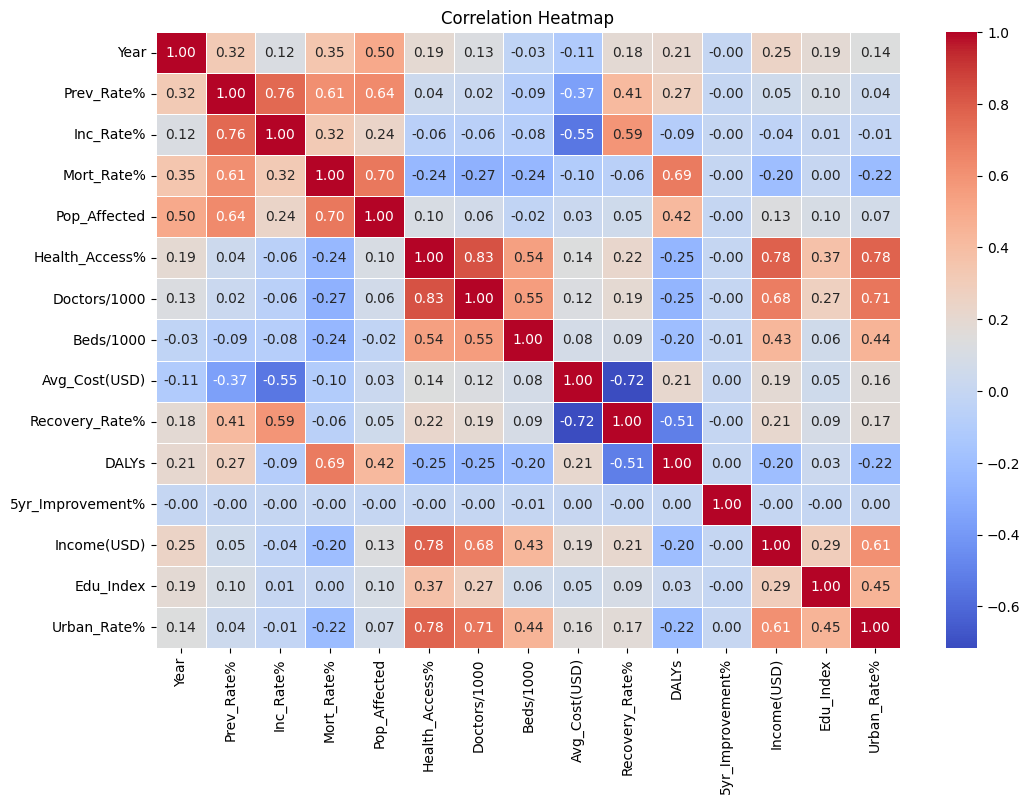

In [26]:
# Filter out non-numeric columns to calculate correlation
numeric_data = df.select_dtypes(include=[float, int]) 

# Compute the correlation matrix for numerical features
correlation_matrix = numeric_data.corr()

# Create the heatmap using seaborn
plt.figure(figsize=(12, 8))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# Show the plot
plt.title("Correlation Heatmap")
plt.show()

##### Identify Relationship of Variables between Target Variable

In [ ]:
from scipy.stats import pearsonr, spearmanr, f_oneway
import pandas as pd

# For numerical features: compute Pearson & Spearman correlations with the target variable "Recovery_Rate%"
numerical_features = df.select_dtypes(include=[float, int]).columns

numerical_corr_results = {}
for feature in numerical_features:
    if feature != 'Recovery_Rate%':
        # Compute Pearson correlation
        pearson_corr, _ = pearsonr(df[feature], df['Recovery_Rate%'])
        # Compute Spearman correlation
        spearman_corr, _ = spearmanr(df[feature], df['Recovery_Rate%'])
        numerical_corr_results[feature] = {
            'Pearson Correlation': pearson_corr,
            'Spearman Correlation': spearman_corr
        }

# For categorical features: compute ANOVA (F-test) to see if Recovery_Rate% differs by groups.
# We include both 'object' and 'category' data types.
categorical_features = df.select_dtypes(include=['object', 'category']).columns

categorical_anova_results = {}
for feature in categorical_features:
    if feature != 'Recovery_Rate%':
        unique_vals = df[feature].unique()
        if len(unique_vals) > 1:
            # Group the target variable by each unique category
            groups = [df[df[feature] == val]['Recovery_Rate%'] for val in unique_vals]
            f_stat, p_value = f_oneway(*groups)
            categorical_anova_results[feature] = {
                'F-statistic': f_stat,
                'p-value': p_value,
                'Levels': len(unique_vals)
            }
        else:
            categorical_anova_results[feature] = {
                'F-statistic': None,
                'p-value': None,
                'Reason': 'Only one unique category'
            }

# Print numerical features correlation results
print("Correlation Results (Numerical Features):")
for feature, corrs in numerical_corr_results.items():
    print(f"{feature}: Pearson = {corrs['Pearson Correlation']:.3f}, Spearman = {corrs['Spearman Correlation']:.3f}")

# Print categorical features ANOVA results
print("\nANOVA Results (Categorical Features):")
for feature, stats in categorical_anova_results.items():
    if stats.get('F-statistic') is not None:
        print(f"{feature}: F-statistic = {stats['F-statistic']:.3f}, p-value = {stats['p-value']:.3f}, Levels = {stats['Levels']}")
    else:
        print(f"{feature}: {stats.get('Reason', 'No result')}")


Correlation Results (Numerical Features):
Year: Pearson = 0.183, Spearman = 0.040
Prev_Rate%: Pearson = 0.413, Spearman = 0.125
Inc_Rate%: Pearson = 0.590, Spearman = 0.369
Mort_Rate%: Pearson = -0.060, Spearman = -0.043
Pop_Affected: Pearson = 0.054, Spearman = -0.464
Health_Access%: Pearson = 0.220, Spearman = 0.229
Doctors/1000: Pearson = 0.193, Spearman = 0.198
Beds/1000: Pearson = 0.093, Spearman = 0.175
Avg_Cost(USD): Pearson = -0.716, Spearman = -0.597
DALYs: Pearson = -0.509, Spearman = -0.580
5yr_Improvement%: Pearson = -0.004, Spearman = -0.003
Income(USD): Pearson = 0.213, Spearman = 0.240
Edu_Index: Pearson = 0.093, Spearman = 0.069
Urban_Rate%: Pearson = 0.172, Spearman = 0.155

ANOVA Results (Categorical Features):
Country: F-statistic = 500.404, p-value = 0.000, Levels = 19
Disease_Name: F-statistic = 264081.036, p-value = 0.000, Levels = 4
Disease_Category: Only one unique category
Age: F-statistic = 0.044, p-value = 0.988, Levels = 4
Gender: F-statistic = 8.209, p-valu

##### Check Skewness

In [6]:
# Step 1: Boxplot for numerical data to check for outliers
numerical_columns = df.select_dtypes(include=[float, int]).columns

skewness = df[numerical_columns].skew()
print("\nSkewness of numerical features:")
print(skewness)


Skewness of numerical features:
Year               -0.214073
Prev_Rate%          0.571828
Inc_Rate%          -0.118169
Mort_Rate%          2.646127
Pop_Affected        1.855012
Health_Access%     -1.175779
Doctors/1000       -0.343726
Beds/1000           1.240486
Avg_Cost(USD)       2.415699
Recovery_Rate%     -1.500546
DALYs               3.636696
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -1.005148
Urban_Rate%        -1.308253
dtype: float64


#### Histogram for Numerical Data

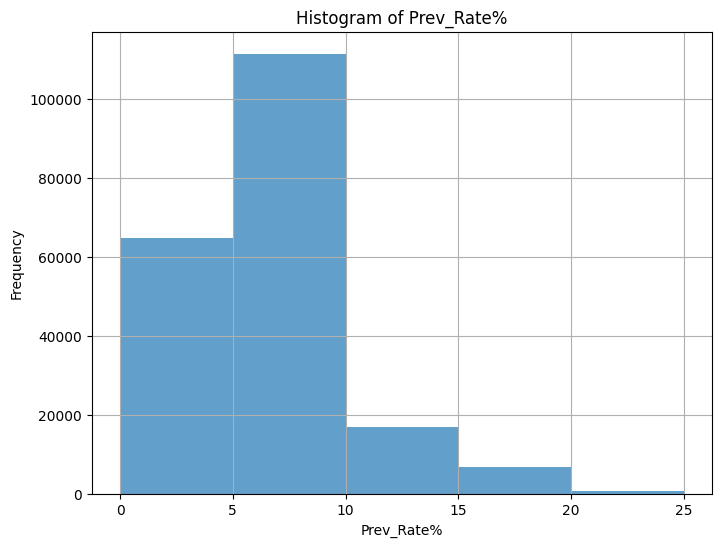

In [29]:
#Prev_Rate%
plt.figure(figsize=(8, 6))
df['Prev_Rate%'].hist(bins=5, alpha=0.7)
plt.title(f'Histogram of Prev_Rate%')
plt.xlabel('Prev_Rate%')
plt.ylabel('Frequency')
plt.show()


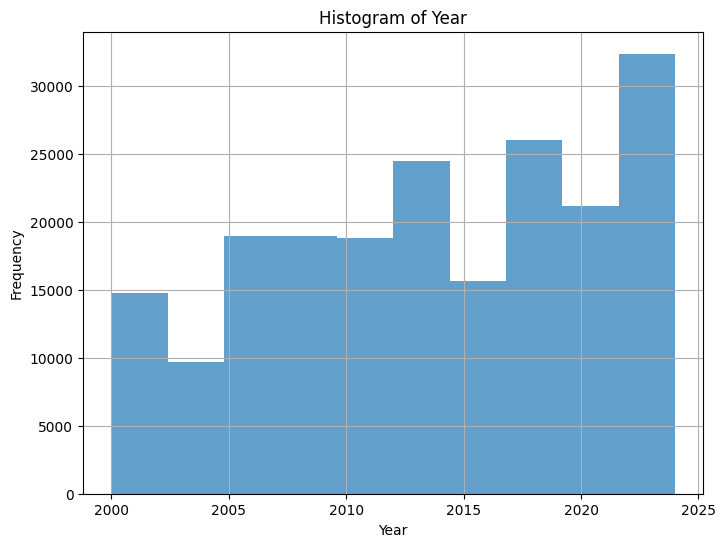

In [30]:
#Year
plt.figure(figsize=(8, 6))
df['Year'].hist(bins=10, alpha=0.7)
plt.title(f'Histogram of Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

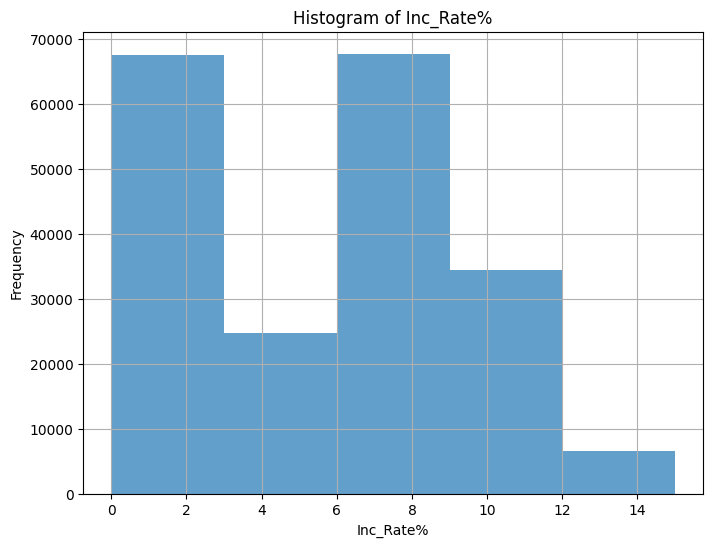

In [31]:
# Inc_Rate%
plt.figure(figsize=(8, 6))
df['Inc_Rate%'].hist(bins=5, alpha=0.7)
plt.title(f'Histogram of Inc_Rate%')
plt.xlabel('Inc_Rate%')
plt.ylabel('Frequency')
plt.show()

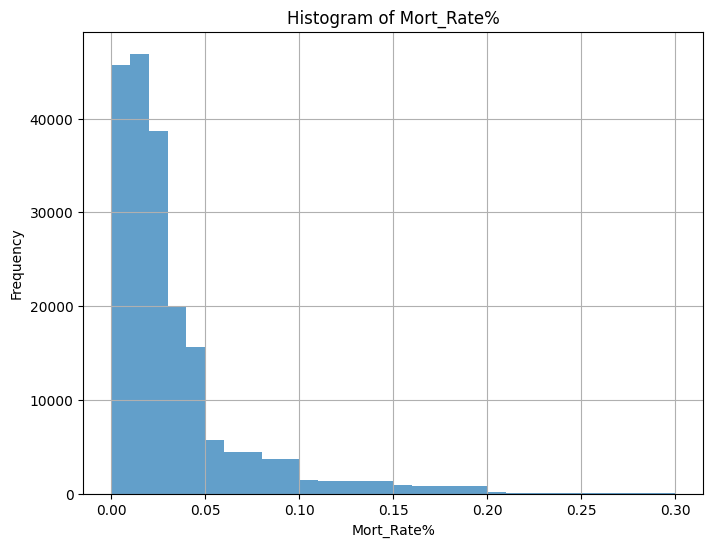

In [32]:
# Mort_Rate%
plt.figure(figsize=(8, 6))
df['Mort_Rate%'].hist(bins=30, alpha=0.7)
plt.title(f'Histogram of Mort_Rate%')
plt.xlabel('Mort_Rate%')
plt.ylabel('Frequency')
plt.show()

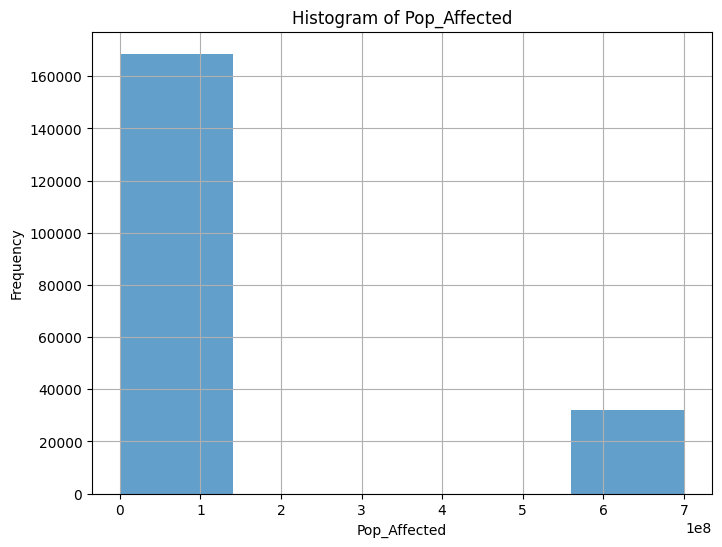

In [33]:
#Pop_Affected
plt.figure(figsize=(8, 6))
df['Pop_Affected'].hist(bins=5, alpha=0.7)
plt.title(f'Histogram of Pop_Affected')
plt.xlabel('Pop_Affected')
plt.ylabel('Frequency')
plt.show()

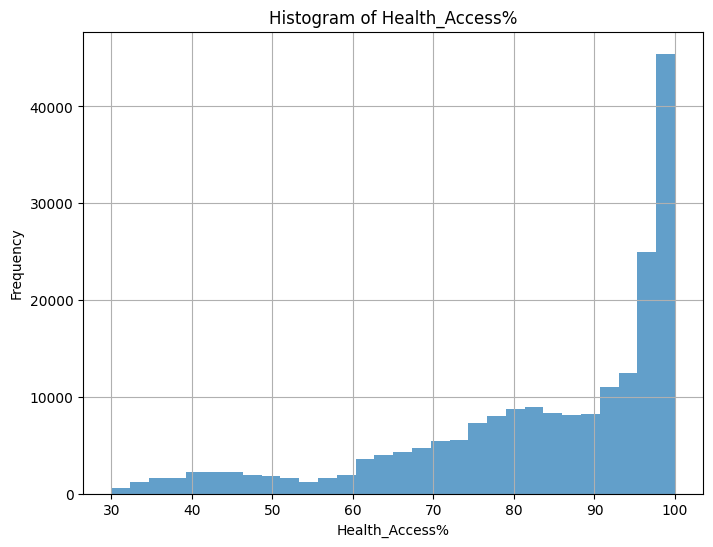

In [34]:
#Health_Access%
plt.figure(figsize=(8, 6))
df['Health_Access%'].hist(bins=30, alpha=0.7)
plt.title(f'Histogram of Health_Access%')
plt.xlabel('Health_Access%')
plt.ylabel('Frequency')
plt.show()

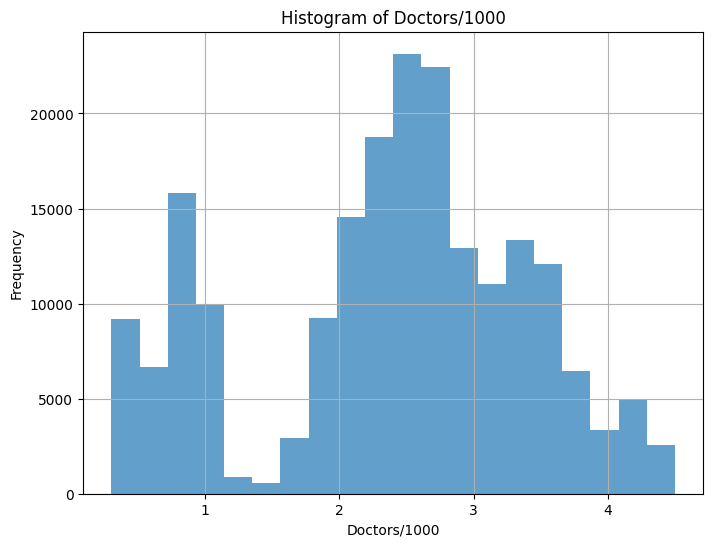

In [35]:
#Doctors/1000
plt.figure(figsize=(8, 6))
df['Doctors/1000'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Doctors/1000')
plt.xlabel('Doctors/1000')
plt.ylabel('Frequency')
plt.show()

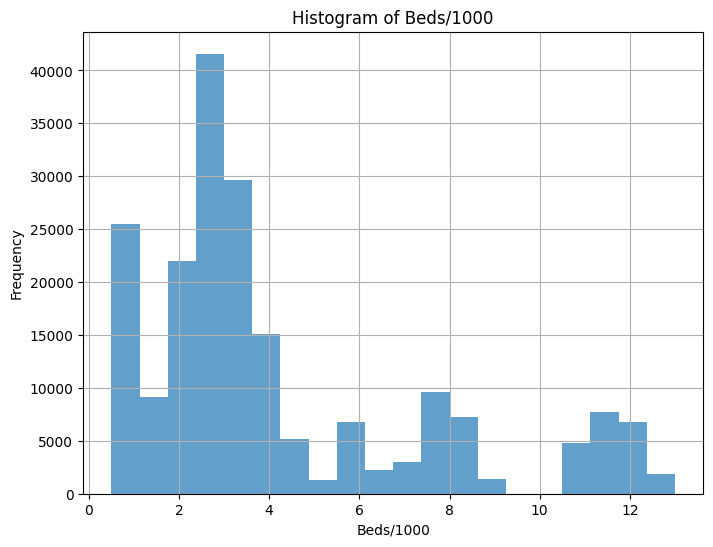

In [36]:
#Beds/1000
plt.figure(figsize=(8, 6))
df['Beds/1000'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Beds/1000')
plt.xlabel('Beds/1000')
plt.ylabel('Frequency')
plt.show()

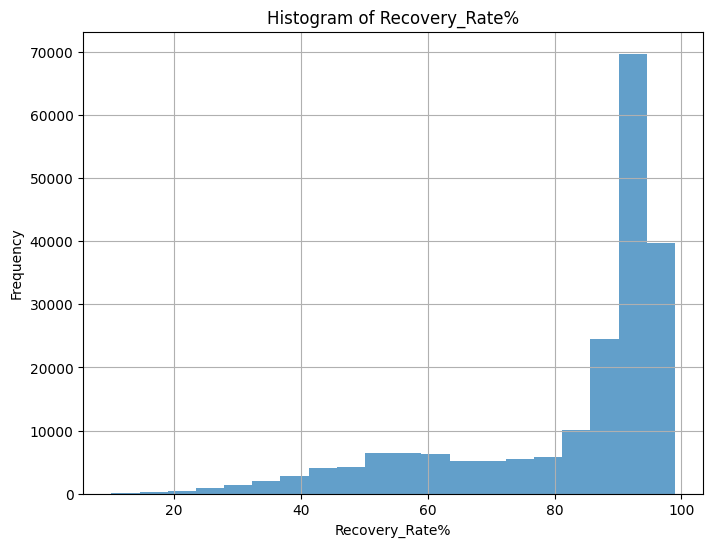

In [37]:
#Recovery_Rate%
plt.figure(figsize=(8, 6))
df['Recovery_Rate%'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Recovery_Rate%')
plt.xlabel('Recovery_Rate%')
plt.ylabel('Frequency')
plt.show()

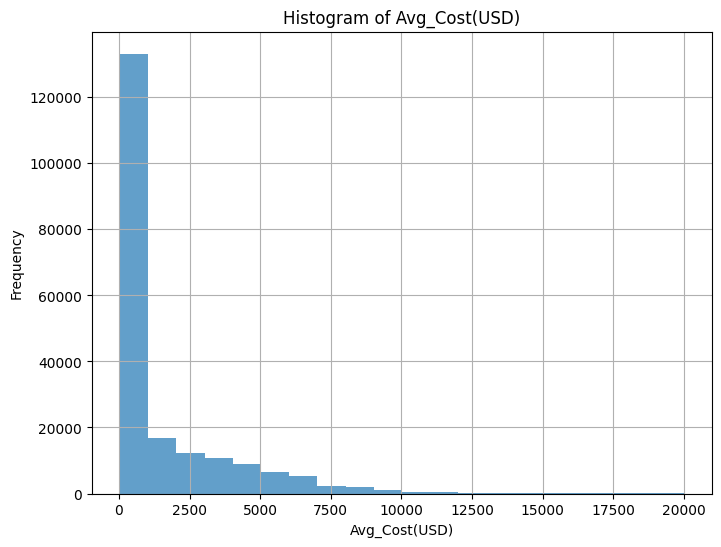

In [38]:
#Avg_Cost(USD)
plt.figure(figsize=(8, 6))
df['Avg_Cost(USD)'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Avg_Cost(USD)')
plt.xlabel('Avg_Cost(USD)')
plt.ylabel('Frequency')
plt.show()

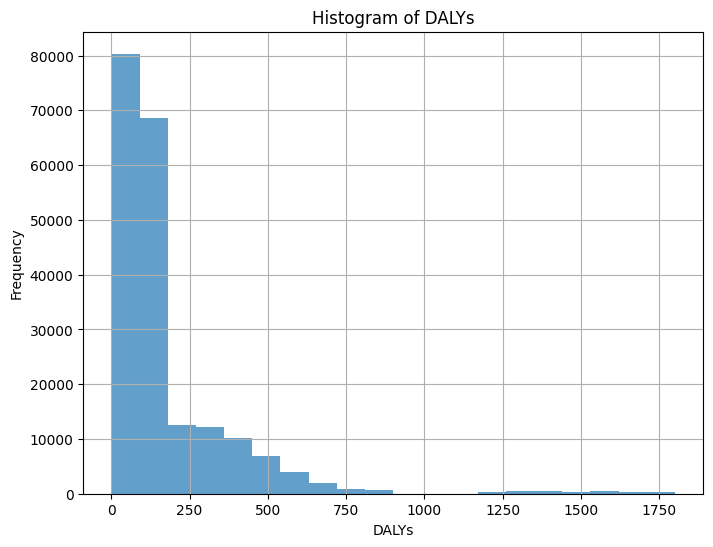

In [39]:
#DALYs 
plt.figure(figsize=(8, 6))
df['DALYs'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of DALYs')
plt.xlabel('DALYs')
plt.ylabel('Frequency')
plt.show()

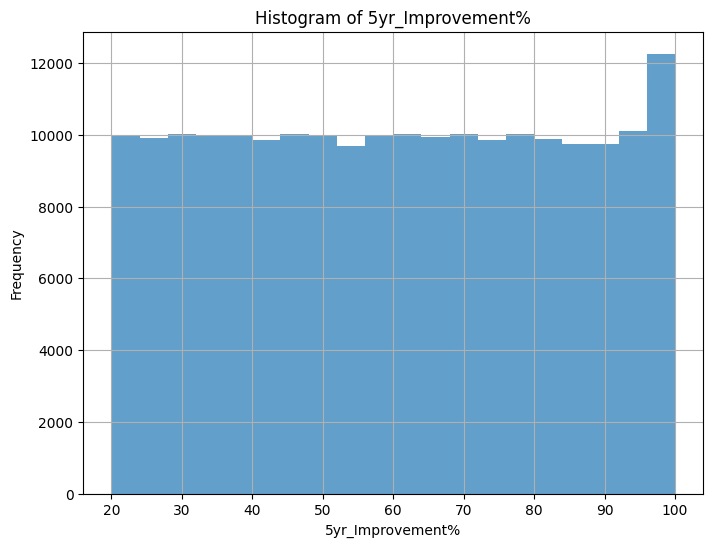

In [40]:
#5yr_Improvement%
plt.figure(figsize=(8, 6))
df['5yr_Improvement%'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of 5yr_Improvement%')
plt.xlabel('5yr_Improvement%')
plt.ylabel('Frequency')
plt.show()

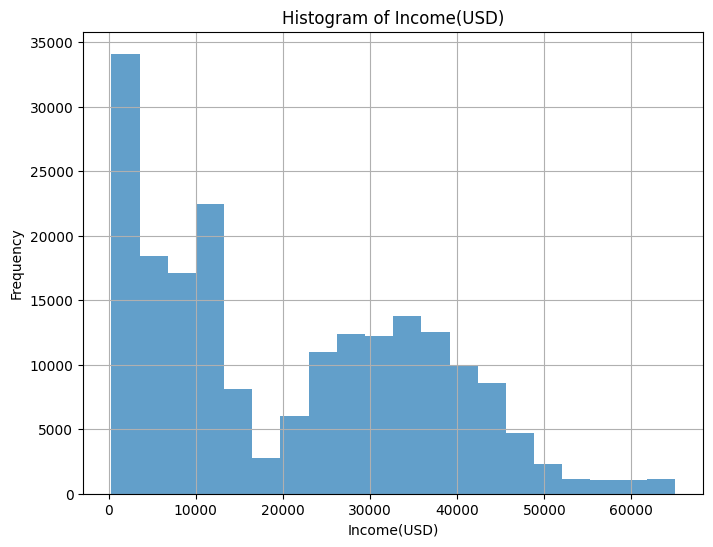

In [41]:
#Income(USD) 
plt.figure(figsize=(8, 6))
df['Income(USD)'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Income(USD)')
plt.xlabel('Income(USD)')
plt.ylabel('Frequency')
plt.show()

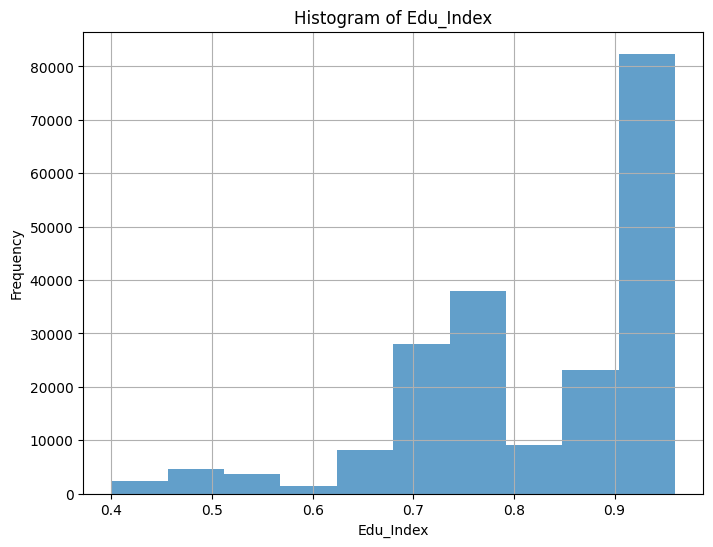

In [42]:
#Edu_Index 
plt.figure(figsize=(8, 6))
df['Edu_Index'].hist(bins=10, alpha=0.7)
plt.title(f'Histogram of Edu_Index')
plt.xlabel('Edu_Index')
plt.ylabel('Frequency')
plt.show()

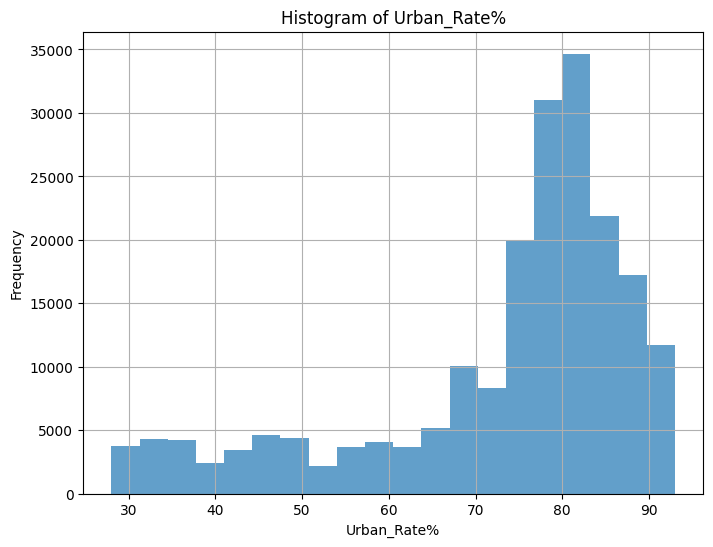

In [43]:
#Urban_Rate% 
plt.figure(figsize=(8, 6))
df['Urban_Rate%'].hist(bins=20, alpha=0.7)
plt.title(f'Histogram of Urban_Rate%')
plt.xlabel('Urban_Rate%')
plt.ylabel('Frequency')
plt.show()

##### Box Plot for Numerical Data

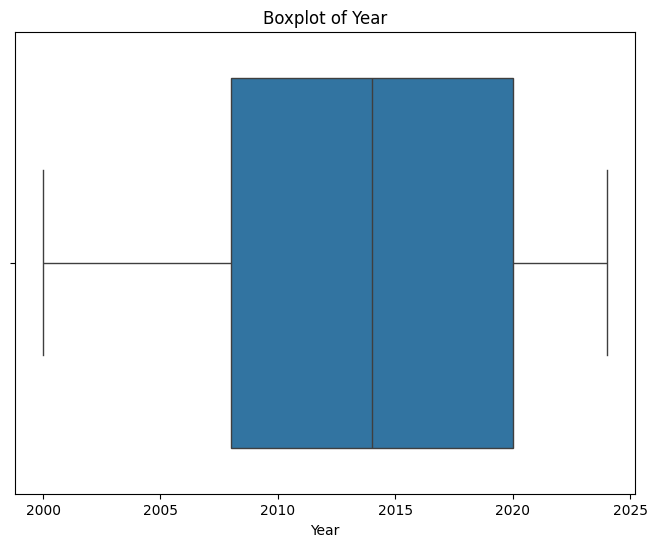

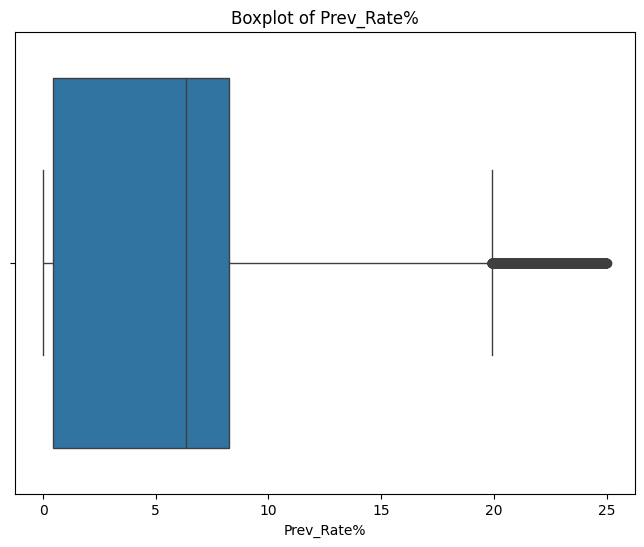

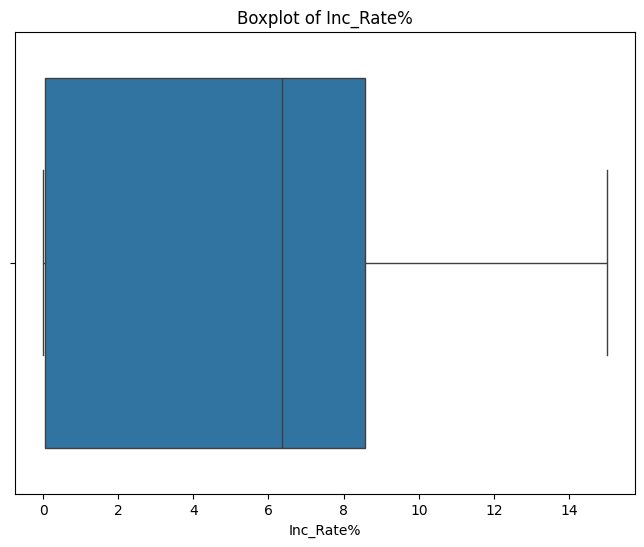

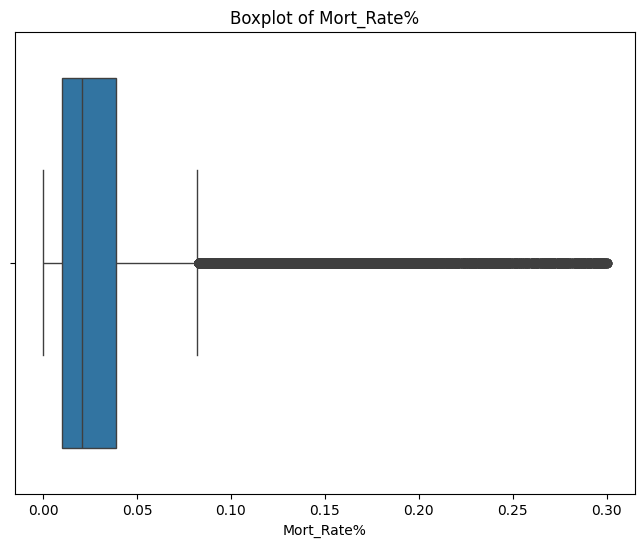

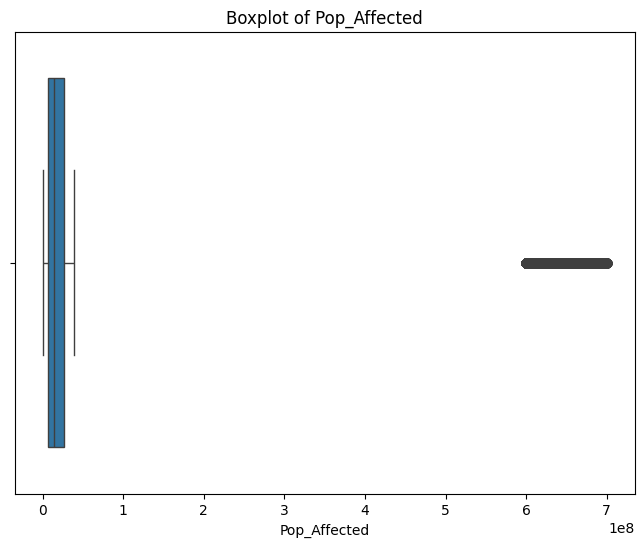

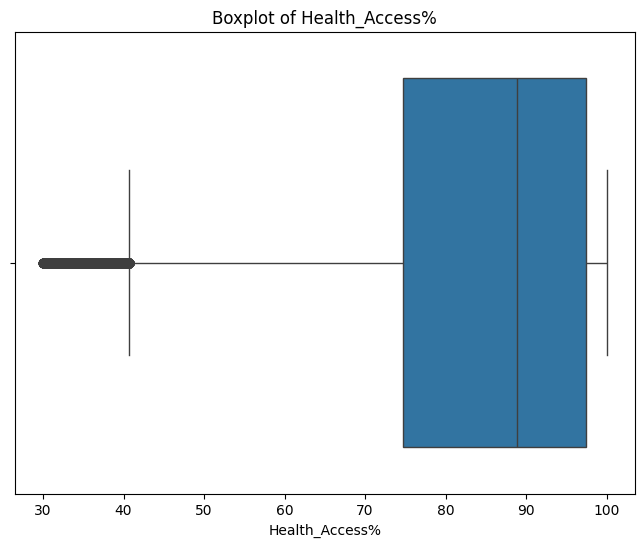

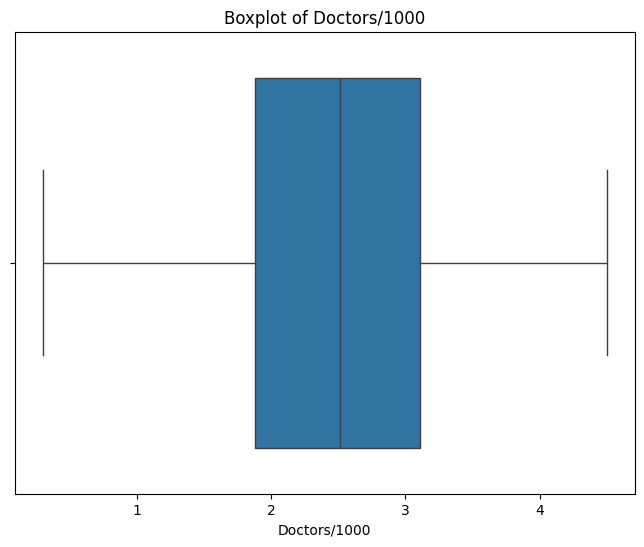

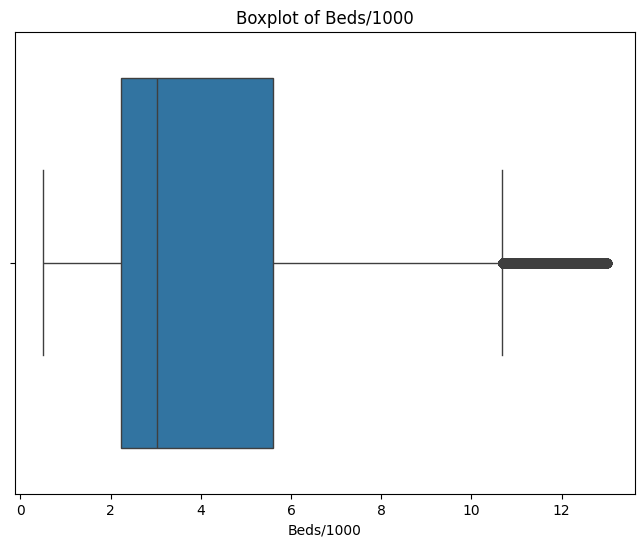

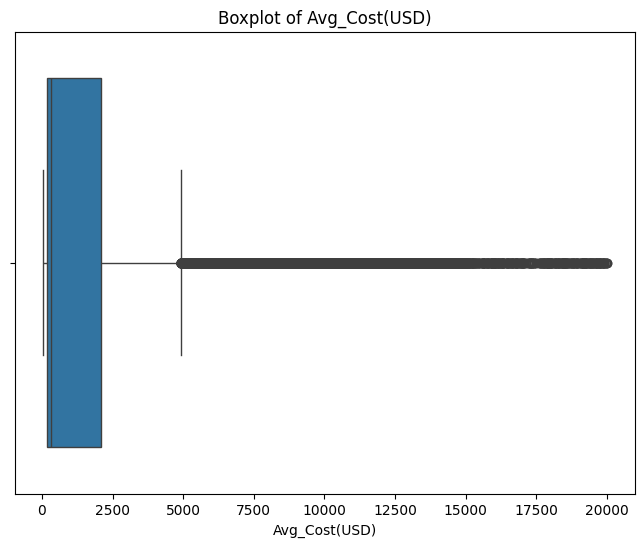

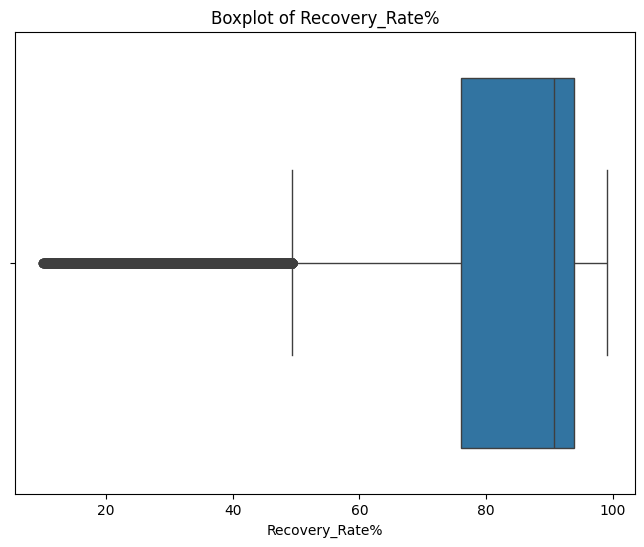

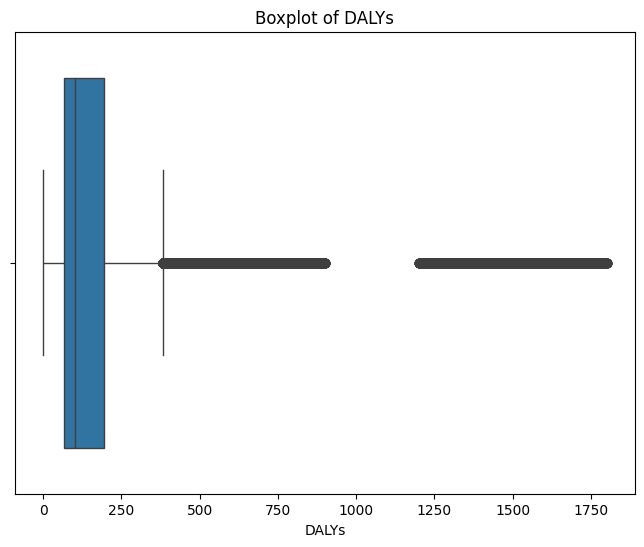

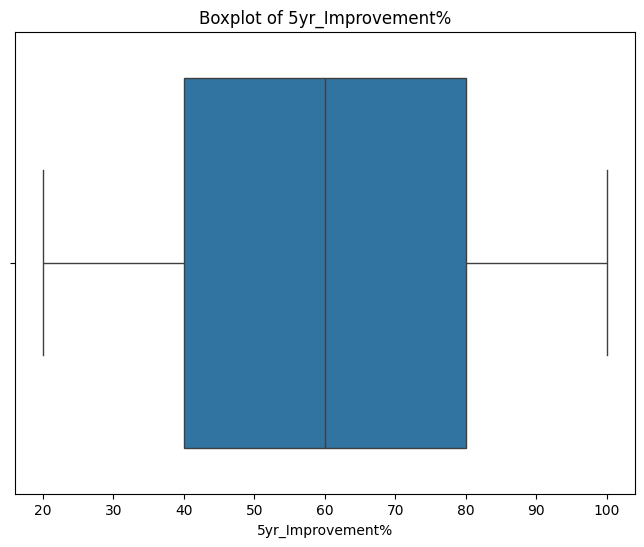

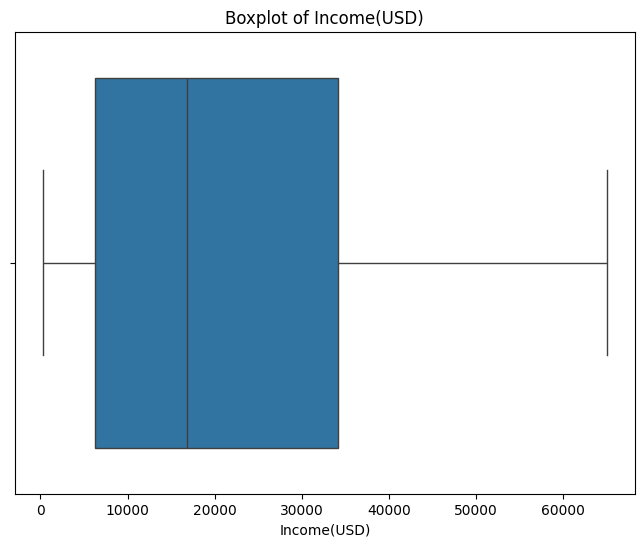

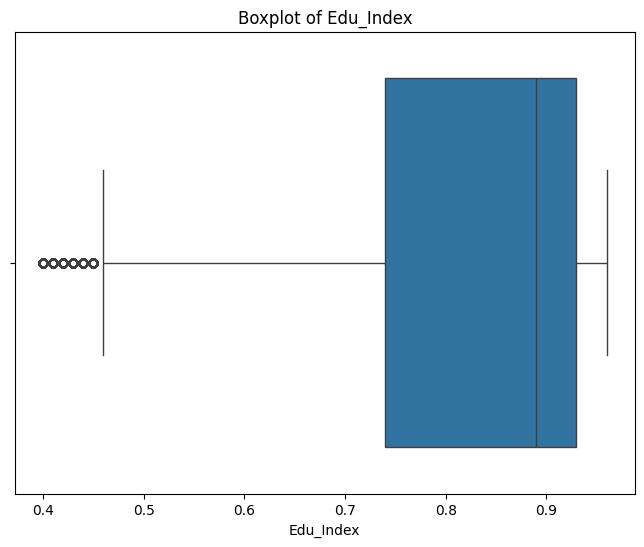

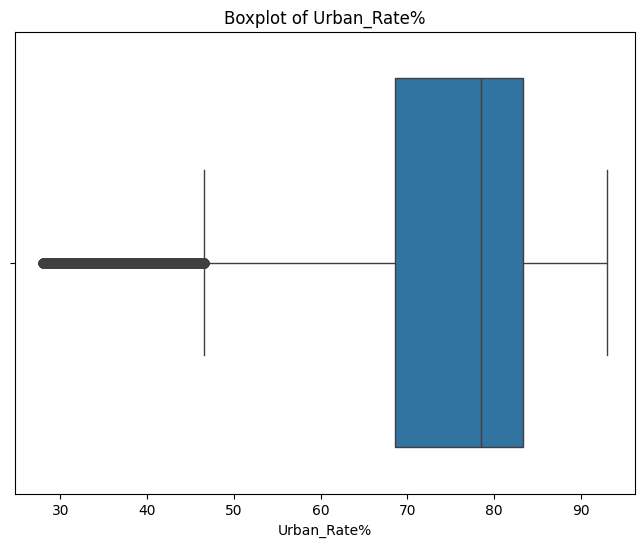

In [44]:
# Step 1: Boxplot for numerical data to check for outliers
numerical_columns = df.select_dtypes(include=[float, int]).columns

# Create a boxplot for each numerical variable
for column in numerical_columns:
    plt.figure(figsize=(8, 6))  # Create a new figure for each plot
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()  # Show each boxplot separately

#### Check Count of Outliers

In [45]:
# Step 1: Identify numerical columns
numerical_columns = df.select_dtypes(include=[float, int]).columns

# Step 2: Count outliers for each numerical column
outliers_count = {}

for column in numerical_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers: values below the lower bound or above the upper bound
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count[column] = outliers.shape[0]

# Step 3: Print the count of outliers for each numerical column
print("Outliers count for each numerical column:")
for column, count in outliers_count.items():
    print(f"{column}: {count} outliers")

Outliers count for each numerical column:
Year: 0 outliers
Prev_Rate%: 935 outliers
Inc_Rate%: 0 outliers
Mort_Rate%: 18277 outliers
Pop_Affected: 32230 outliers
Health_Access%: 6171 outliers
Doctors/1000: 0 outliers
Beds/1000: 19847 outliers
Avg_Cost(USD): 19810 outliers
Recovery_Rate%: 15205 outliers
DALYs: 24155 outliers
5yr_Improvement%: 0 outliers
Income(USD): 0 outliers
Edu_Index: 2408 outliers
Urban_Rate%: 21293 outliers


#### Bar Chart for Category Data

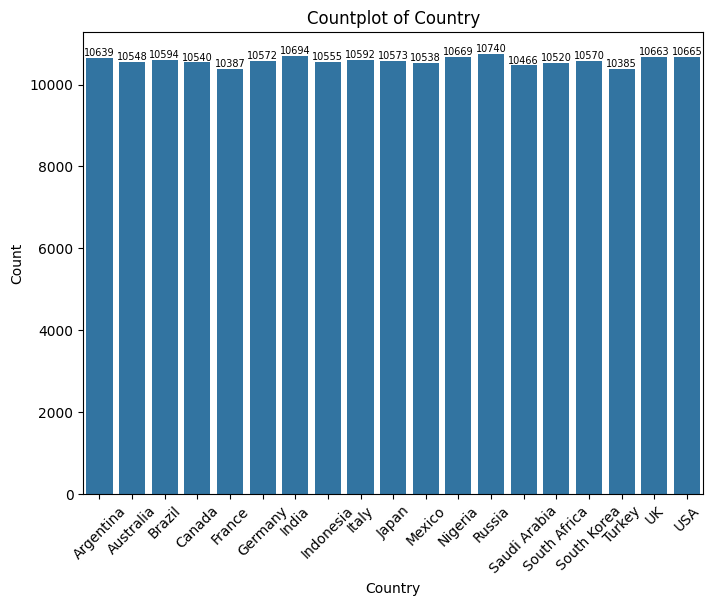

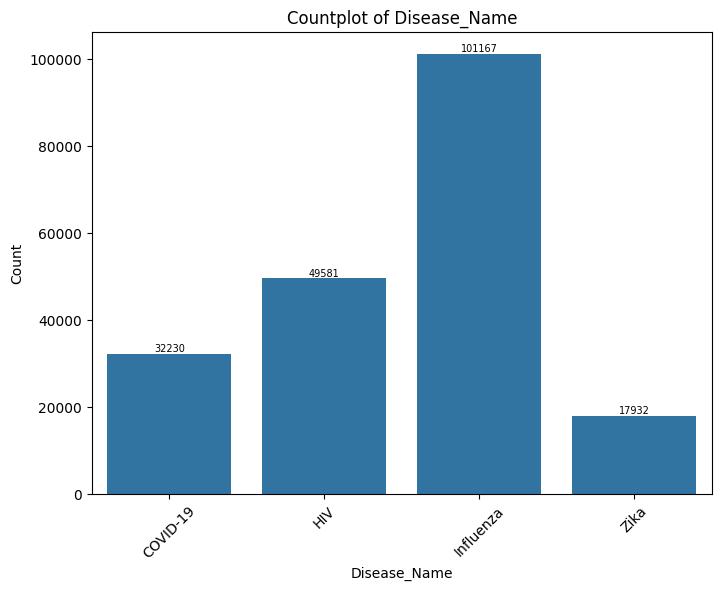

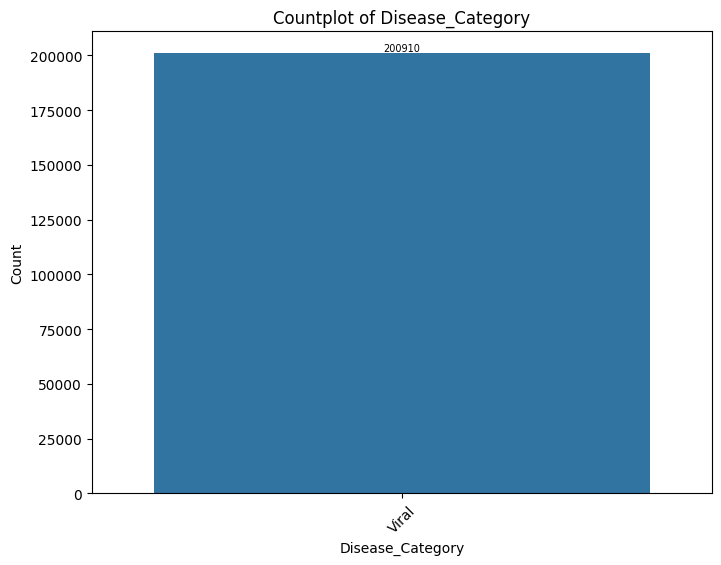

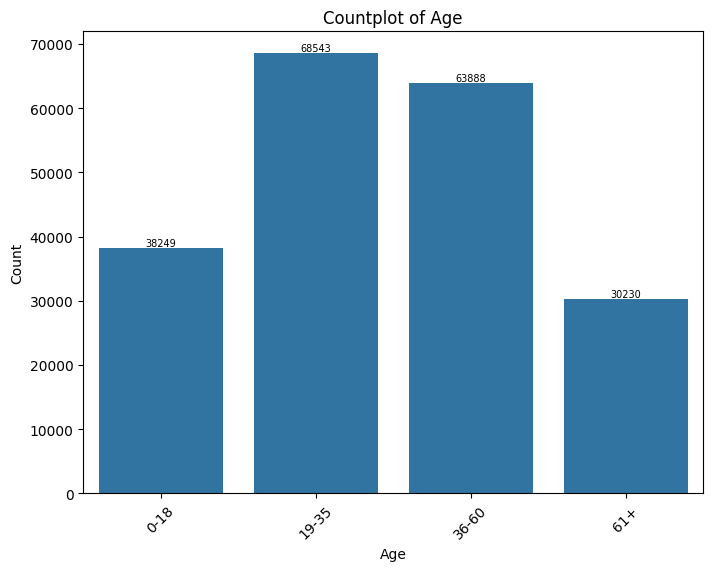

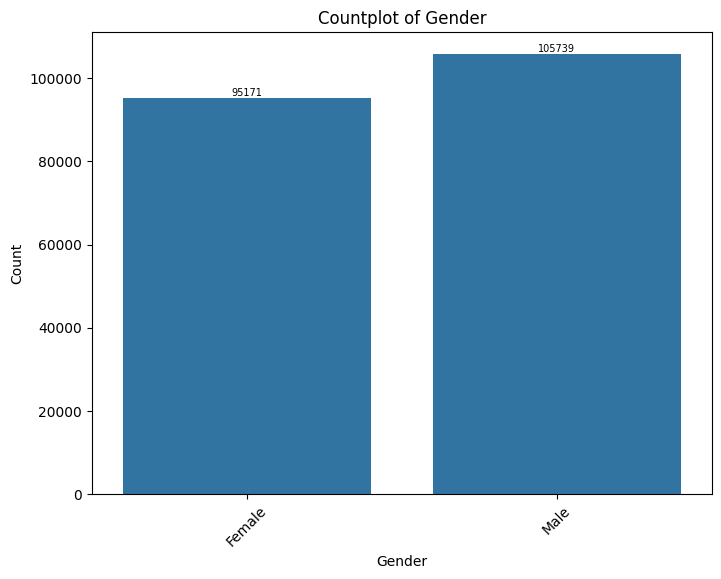

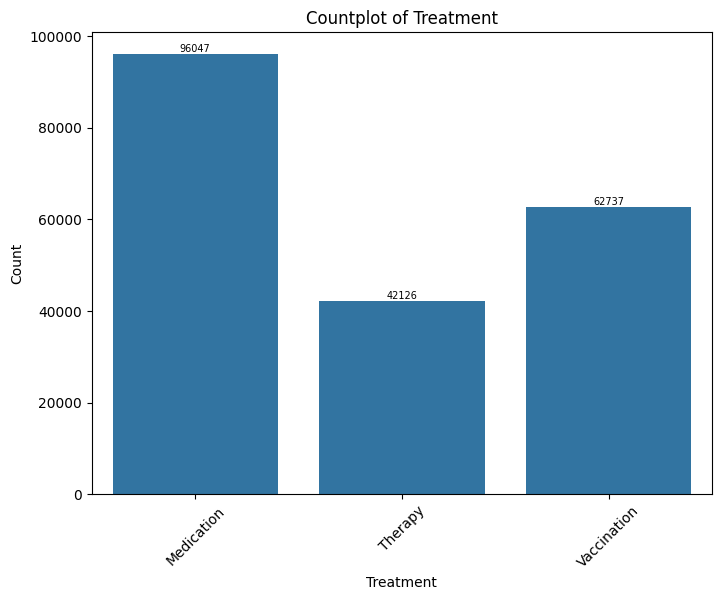

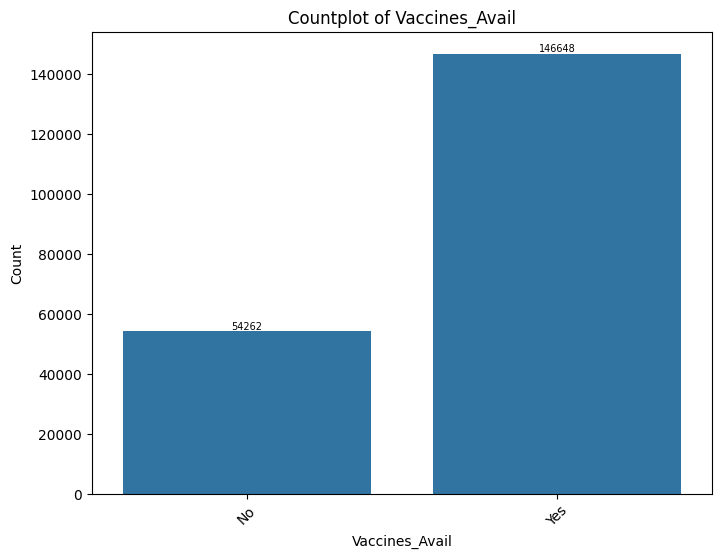

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Categorical data exploration - Countplot for each categorical variable
categorical_columns = df.select_dtypes(include=['category']).columns

# Create a countplot for each categorical variable in a separate image
for column in categorical_columns:
    plt.figure(figsize=(8, 6))  # Create a new figure for each categorical variable
    ax = sns.countplot(x=df[column])
    
    # Add count annotations on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=7, color='black')

    plt.title(f'Countplot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # Rotate x labels if needed
    plt.show()  # Show each countplot separately


#### Histogram for Age

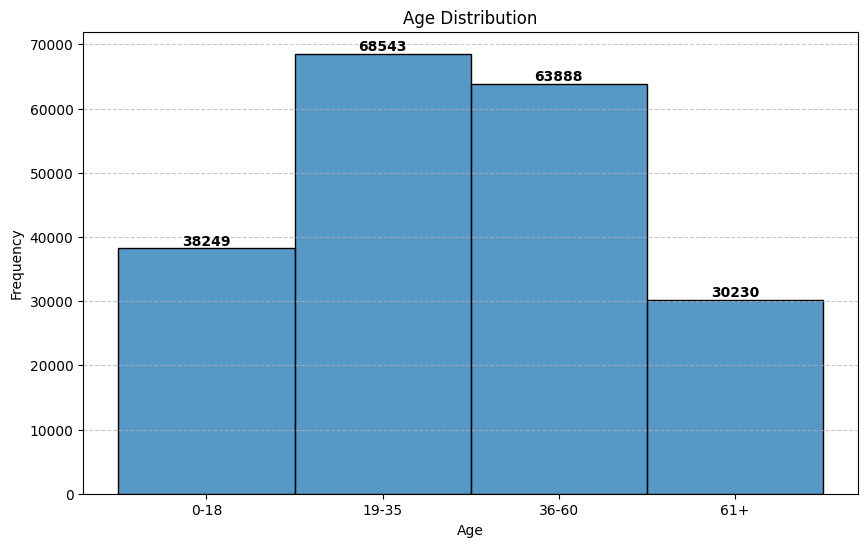

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Plot a histogram for the 'Age' column
plt.figure(figsize=(10, 6))  # Adjust the figure size
ax = sns.histplot(df['Age'], bins=30, kde=False)  # Histogram with KDE

# Add count annotations on top of the bars
for p in ax.patches:
    if p.get_height() > 0:  # Only annotate bars with height > 0
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.show()

# Step 2: Print Frequency count for 'Age'


#### Pie Chart for Gender

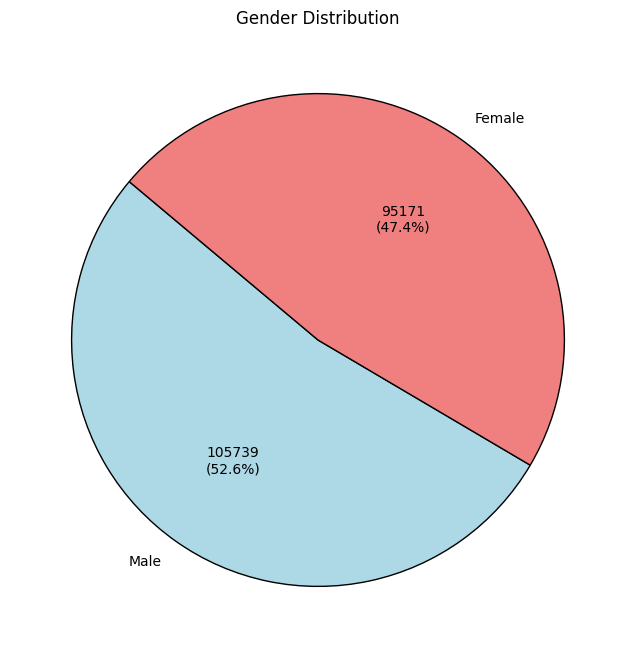

In [48]:
import matplotlib.pyplot as plt

# Step 1: Get the counts for each gender category
gender_counts = df['Gender'].value_counts()

# Step 2: Define a function to display count and percentage
def autopct_format(pct, all_values):
    absolute = int(round(pct/100. * sum(all_values)))
    return f'{absolute}\n({pct:.1f}%)'  # Shows both count and percentage

# Step 3: Create a pie chart with count labels
plt.figure(figsize=(8, 8))  # Adjust figure size
plt.pie(gender_counts, labels=gender_counts.index, autopct=lambda pct: autopct_format(pct, gender_counts),
        startangle=140, colors=['lightblue', 'lightcoral'], wedgeprops={'edgecolor': 'black'})

# Step 4: Add title and display the chart
plt.title('Gender Distribution')
plt.show()


##### Pie Chart for Gender

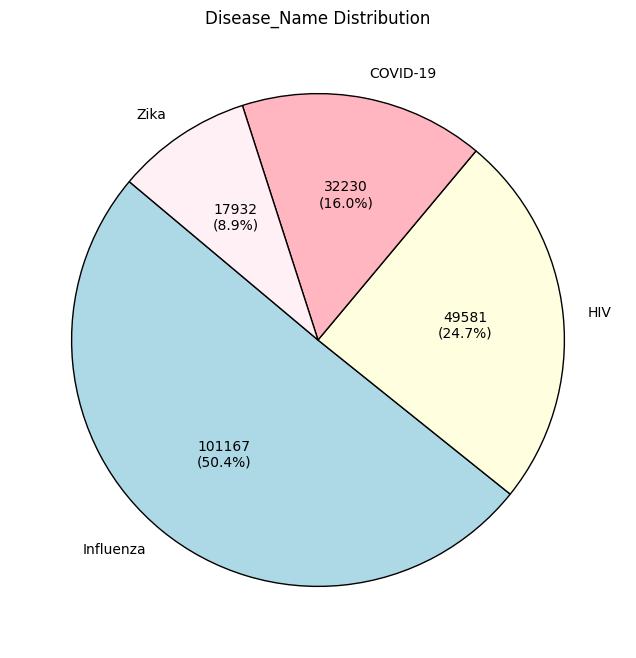

In [49]:
import matplotlib.pyplot as plt

# Step 1: Get the counts for each gender category
gender_counts = df['Disease_Name'].value_counts()

# Step 2: Define a function to display count and percentage
def autopct_format(pct, all_values):
    absolute = int(round(pct/100. * sum(all_values)))
    return f'{absolute}\n({pct:.1f}%)'  # Shows both count and percentage

# Step 3: Create a pie chart with count labels
plt.figure(figsize=(8, 8))  # Adjust figure size
plt.pie(gender_counts, labels=gender_counts.index, autopct=lambda pct: autopct_format(pct, gender_counts),
        startangle=140, colors=['lightblue', 'lightyellow','lightpink','lavenderblush'], wedgeprops={'edgecolor': 'black'})

# Step 4: Add title and display the chart
plt.title('Disease_Name Distribution')
plt.show()


##### Pie Chart for Vaccines_Avail

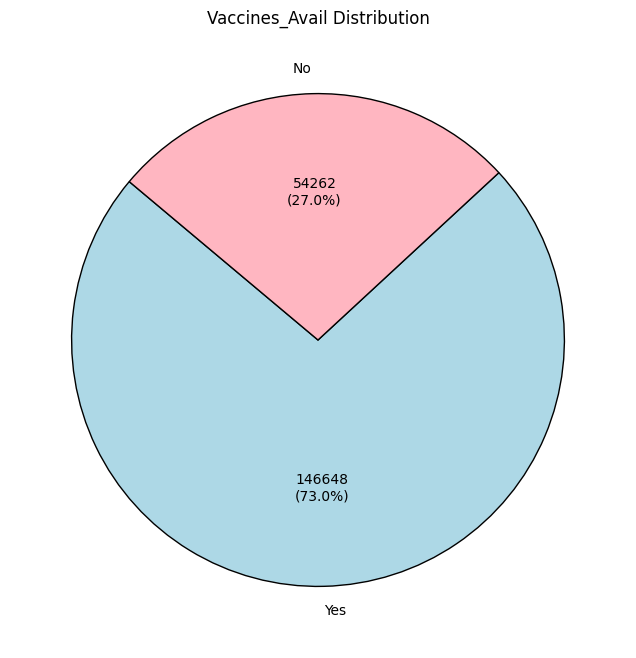

In [50]:
import matplotlib.pyplot as plt

# Step 1: Get the counts for each gender category
gender_counts = df['Vaccines_Avail'].value_counts()

# Step 2: Define a function to display count and percentage
def autopct_format(pct, all_values):
    absolute = int(round(pct/100. * sum(all_values)))
    return f'{absolute}\n({pct:.1f}%)'  # Shows both count and percentage

# Step 3: Create a pie chart with count labels
plt.figure(figsize=(8, 8))  # Adjust figure size
plt.pie(gender_counts, labels=gender_counts.index, autopct=lambda pct: autopct_format(pct, gender_counts),
        startangle=140, colors=['lightblue','lightpink'], wedgeprops={'edgecolor': 'black'})

# Step 4: Add title and display the chart
plt.title('Vaccines_Avail Distribution')
plt.show()


### 2.0 Data Preprocessing

#### Handle Right-skewed（Positive Skewness) Attributes (Log Transformation + Box Cox)

In [7]:
from scipy import stats
#Backup data
df1=df

# Check skewness before Logs Transformation
numerical_columns = df.select_dtypes(include=[float, int]).columns
skewness = df[numerical_columns].skew()
print("\nSkewness of numerical features before:")
print(skewness)

#Logs Tranformation
df1['Pop_Affected'] = np.log(df1['Pop_Affected'] + 1)
df1['Avg_Cost(USD)'] = np.log(df1['Avg_Cost(USD)'] + 1)
df1['Beds/1000'] = np.log(df1['Beds/1000'] + 1)

# Box-Cox transformation for Mort_Rate% and DALYs (data needs to be positive)
df1['Mort_Rate%'], _ = stats.boxcox(df1['Mort_Rate%'] + 1)  # Adding 1 to avoid zero
df1['DALYs'], _ = stats.boxcox(df1['DALYs'] + 1)  # Adding 1 to avoid zero

# Check skewness after Logs Transformation
numerical_columns = df1.select_dtypes(include=[float, int]).columns
skewness = df1[numerical_columns].skew()
print("\nSkewness of numerical features after:")
print(skewness)


Skewness of numerical features before:
Year               -0.214073
Prev_Rate%          0.571828
Inc_Rate%          -0.118169
Mort_Rate%          2.646127
Pop_Affected        1.855012
Health_Access%     -1.175779
Doctors/1000       -0.343726
Beds/1000           1.240486
Avg_Cost(USD)       2.415699
Recovery_Rate%     -1.500546
DALYs               3.636696
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -1.005148
Urban_Rate%        -1.308253
dtype: float64


C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3828591911.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Pop_Affected'] = np.log(df1['Pop_Affected'] + 1)
C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3828591911.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Avg_Cost(USD)'] = np.log(df1['Avg_Cost(USD)'] + 1)
C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3828591911.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc


Skewness of numerical features after:
Year               -0.214073
Prev_Rate%          0.571828
Inc_Rate%          -0.118169
Mort_Rate%          0.387270
Pop_Affected        0.822604
Health_Access%     -1.175779
Doctors/1000       -0.343726
Beds/1000           0.298612
Avg_Cost(USD)       0.603148
Recovery_Rate%     -1.500546
DALYs               0.079150
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -1.005148
Urban_Rate%        -1.308253
dtype: float64


C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3828591911.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['DALYs'], _ = stats.boxcox(df1['DALYs'] + 1)  # Adding 1 to avoid zero


#### Handle Left-skewed(Negative Skewness) Attributes (Box-cox)

In [8]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
import numpy as np
import scipy.stats.mstats as mstats

#Backup data
df2=df1

# Check skewness before Logs Transformation
numerical_columns = df1.select_dtypes(include=[float, int]).columns
skewness = df1[numerical_columns].skew()
print("\nSkewness of numerical features:")
print(skewness)

# Box-Cox Transformation (data needs to be positive)
df2['Health_Access%'], _ = stats.boxcox(df2['Health_Access%'] + 1)
df2['Edu_Index'], _ = stats.boxcox(df2['Edu_Index'] + 1)
df2['Urban_Rate%'], _ = stats.boxcox(df2['Urban_Rate%'] + 1)


# Check skewness after Logs Transformation
numerical_columns = df2.select_dtypes(include=[float, int]).columns
skewness = df2[numerical_columns].skew()
print("\nSkewness of numerical features:")
print(skewness)


Skewness of numerical features:
Year               -0.214073
Prev_Rate%          0.571828
Inc_Rate%          -0.118169
Mort_Rate%          0.387270
Pop_Affected        0.822604
Health_Access%     -1.175779
Doctors/1000       -0.343726
Beds/1000           0.298612
Avg_Cost(USD)       0.603148
Recovery_Rate%     -1.500546
DALYs               0.079150
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -1.005148
Urban_Rate%        -1.308253
dtype: float64


C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3534911532.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Health_Access%'], _ = stats.boxcox(df2['Health_Access%'] + 1)
C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3534911532.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Edu_Index'], _ = stats.boxcox(df2['Edu_Index'] + 1)



Skewness of numerical features:
Year               -0.214073
Prev_Rate%          0.571828
Inc_Rate%          -0.118169
Mort_Rate%          0.387270
Pop_Affected        0.822604
Health_Access%     -0.411267
Doctors/1000       -0.343726
Beds/1000           0.298612
Avg_Cost(USD)       0.603148
Recovery_Rate%     -1.500546
DALYs               0.079150
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -0.274106
Urban_Rate%        -0.397800
dtype: float64


C:\Users\limju\AppData\Local\Temp\ipykernel_23568\3534911532.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Urban_Rate%'], _ = stats.boxcox(df2['Urban_Rate%'] + 1)


#### Check Outlier after Adjust Skewness

In [9]:
# Step 1: Identify numerical columns
numerical_columns = df.select_dtypes(include=[float, int]).columns

# Step 2: Count outliers for each numerical column
outliers_count = {}

for column in numerical_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers: values below the lower bound or above the upper bound
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count[column] = outliers.shape[0]

# Step 3: Print the count of outliers for each numerical column
print("Outliers count for each numerical column:")
for column, count in outliers_count.items():
    print(f"{column}: {count} outliers")

Outliers count for each numerical column:
Year: 0 outliers
Prev_Rate%: 935 outliers
Inc_Rate%: 0 outliers
Mort_Rate%: 0 outliers
Pop_Affected: 33211 outliers
Health_Access%: 0 outliers
Doctors/1000: 0 outliers
Beds/1000: 0 outliers
Avg_Cost(USD): 0 outliers
Recovery_Rate%: 15205 outliers
DALYs: 23105 outliers
5yr_Improvement%: 0 outliers
Income(USD): 0 outliers
Edu_Index: 0 outliers
Urban_Rate%: 0 outliers


#### Handle Outlier -Capping Method 

In [10]:
# Backup data
df3 = df2.copy()

# List of specific numerical variables to handle outliers
variables_to_handle = ['Prev_Rate%', 'Pop_Affected', 'DALYs']

# Step 1: Apply winsorization (capping) on each numerical column based on IQR
for column in variables_to_handle:
    # Calculate the IQR
    Q1 = df3[column].quantile(0.25)
    Q3 = df3[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply custom winsorization: cap outliers at the bounds
    df3[column] = np.where(df3[column] < lower_bound, lower_bound, df3[column])  # Cap below lower bound
    df3[column] = np.where(df3[column] > upper_bound, upper_bound, df3[column])  # Cap above upper bound

# Step 2: Check the outlier count

# Identify numerical columns
numerical_columns = df3.select_dtypes(include=[float, int]).columns

# Count outliers for each numerical column
outliers_count = {}

for column in numerical_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df3[column].quantile(0.25)
    Q3 = df3[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers: values below the lower bound or above the upper bound
    outliers = df3[(df3[column] < lower_bound) | (df3[column] > upper_bound)]
    outliers_count[column] = outliers.shape[0]

# Print the count of outliers for each numerical column
print("Outliers count for each numerical column:")
for column, count in outliers_count.items():
    print(f"{column}: {count} outliers")


# Step 3: Check skewness after Data preprocessing
numerical_columns = df3.select_dtypes(include=[float, int]).columns

skewness = df3[numerical_columns].skew()
print("\nSkewness of numerical features:")
print(skewness)

Outliers count for each numerical column:
Year: 0 outliers
Prev_Rate%: 0 outliers
Inc_Rate%: 0 outliers
Mort_Rate%: 0 outliers
Pop_Affected: 0 outliers
Health_Access%: 0 outliers
Doctors/1000: 0 outliers
Beds/1000: 0 outliers
Avg_Cost(USD): 0 outliers
Recovery_Rate%: 15205 outliers
DALYs: 0 outliers
5yr_Improvement%: 0 outliers
Income(USD): 0 outliers
Edu_Index: 0 outliers
Urban_Rate%: 0 outliers

Skewness of numerical features:
Year               -0.214073
Prev_Rate%          0.508183
Inc_Rate%          -0.118169
Mort_Rate%          0.387270
Pop_Affected        0.391750
Health_Access%     -0.411267
Doctors/1000       -0.343726
Beds/1000           0.298612
Avg_Cost(USD)       0.603148
Recovery_Rate%     -1.500546
DALYs               0.035845
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -0.274106
Urban_Rate%        -0.397800
dtype: float64


#### Data Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
df4=df3.copy()

# Select numerical columns for scaling
numerical_columns = df4.select_dtypes(include=[float, int]).columns
numerical_column = numerical_columns.drop(['Pop_Affected', 'Year'])

# Standard Scaler
scaler = StandardScaler()  

# Apply the scaler to the numerical columns
df4[numerical_column] = scaler.fit_transform(df4[numerical_column])


# Summary Statistic for Numeric Columns
print("\nDescriptive Statistics df2:")
print(df2.describe()) 

# Summary Statistic for Numeric Columns
print("\nDescriptive Statistics df4:")
print(df4.describe()) 




Descriptive Statistics df2:
                Year     Prev_Rate%  ...      Edu_Index   Urban_Rate%
count  200910.000000  200910.000000  ...  200910.000000  2.009100e+05
mean     2013.616077       5.815497  ...      16.930281  1.034167e+06
std         6.913517       4.605412  ...       7.409936  5.135477e+05
min      2000.000000       0.000000  ...       1.721811  3.406066e+04
25%      2008.000000       0.460000  ...      10.400900  7.096423e+05
50%      2014.000000       6.350000  ...      20.280237  1.128528e+06
75%      2020.000000       8.240000  ...      24.004699  1.379389e+06
max      2024.000000      25.000000  ...      27.175843  2.012567e+06

[8 rows x 15 columns]

Descriptive Statistics df4:
                Year    Prev_Rate%  ...     Edu_Index   Urban_Rate%
count  200910.000000  2.009100e+05  ...  2.009100e+05  2.009100e+05
mean     2013.616077 -3.328669e-16  ... -1.028803e-16 -5.046052e-16
std         6.913517  1.000002e+00  ...  1.000002e+00  1.000002e+00
min      2000.000

### 3.0 Data Understanding 

#### Basic Info

##### Missing Value & Duplicate Code

In [14]:
#Back up
final_df=df4
print(tabulate(final_df.head(5), headers='keys', tablefmt='pretty'))

#Check Missing Value & Data Type
print("\nData Information:")
final_df.info()

# Summary Statistic for Numeric Columns
print("\nDescriptive Statistics:")
print(final_df.describe()) 

# Summarize categorical variables
categorical_summary = {}
for column in final_df.select_dtypes(include=['category']).columns:
    categorical_summary[column] = final_df[column].nunique(), final_df[column].unique()
    
print("\nCategorical Data Summary:")
for column, (n_types, unique_values) in categorical_summary.items():
    print(f"{column}: {n_types} unique values \n - {unique_values}\n")

# Check for missing values
print("\nMissing Values:")
print(final_df.isnull().sum())  

# Check for duplicate rows
print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

+---+-----------+------+--------------+------------------+----------------------+--------------------+----------------------+-------+--------+--------------------+----------------------+----------------------+----------------------+-------------+---------------------+----------------+---------------------+----------------------+--------------------+---------------------+---------------------+----------------------+
|   |  Country  | Year | Disease_Name | Disease_Category |      Prev_Rate%      |     Inc_Rate%      |      Mort_Rate%      |  Age  | Gender |    Pop_Affected    |    Health_Access%    |     Doctors/1000     |      Beds/1000       |  Treatment  |    Avg_Cost(USD)    | Vaccines_Avail |   Recovery_Rate%    |        DALYs         |  5yr_Improvement%  |     Income(USD)     |      Edu_Index      |     Urban_Rate%      |
+---+-----------+------+--------------+------------------+----------------------+--------------------+----------------------+-------+--------+--------------------

##### Check Skewness

In [60]:
# Step 1: Boxplot for numerical data to check for outliers
numerical_columns = final_df.select_dtypes(include=[float, int]).columns

skewness = final_df[numerical_columns].skew()
print("\nSkewness of numerical features:")
print(skewness)


Skewness of numerical features:
Year               -0.214073
Prev_Rate%          0.508183
Inc_Rate%          -0.118169
Mort_Rate%          0.387270
Pop_Affected        0.391750
Health_Access%     -0.411267
Doctors/1000       -0.343726
Beds/1000           0.298612
Avg_Cost(USD)       0.603148
Recovery_Rate%     -1.500546
DALYs               0.035845
5yr_Improvement%    0.003566
Income(USD)         0.409729
Edu_Index          -0.274106
Urban_Rate%        -0.397800
dtype: float64


##### Box Plot for Numerical Data

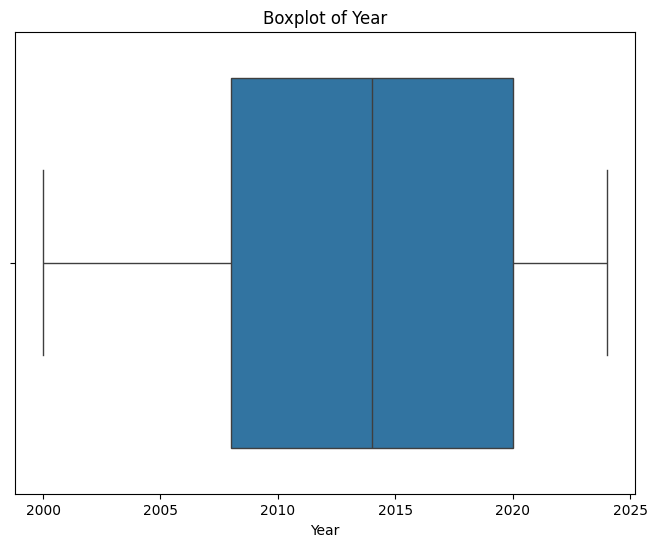

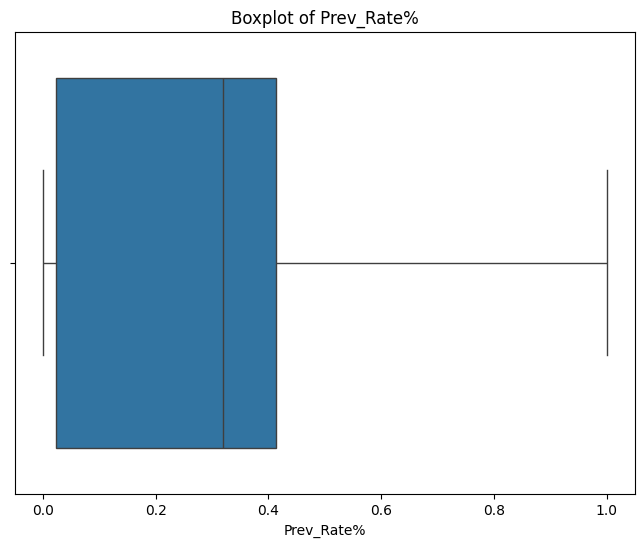

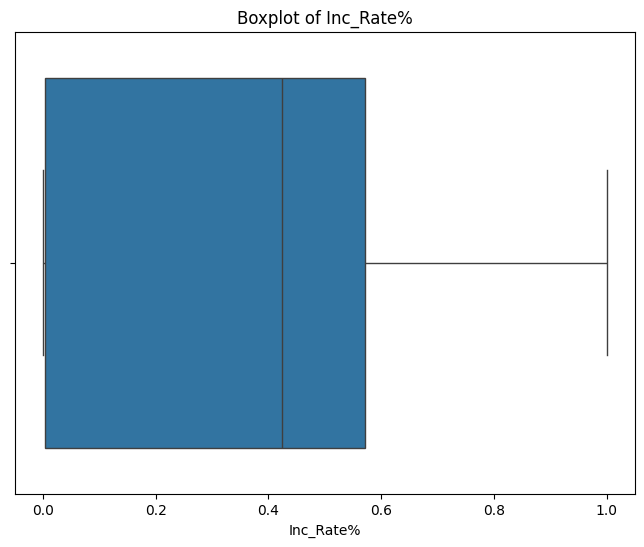

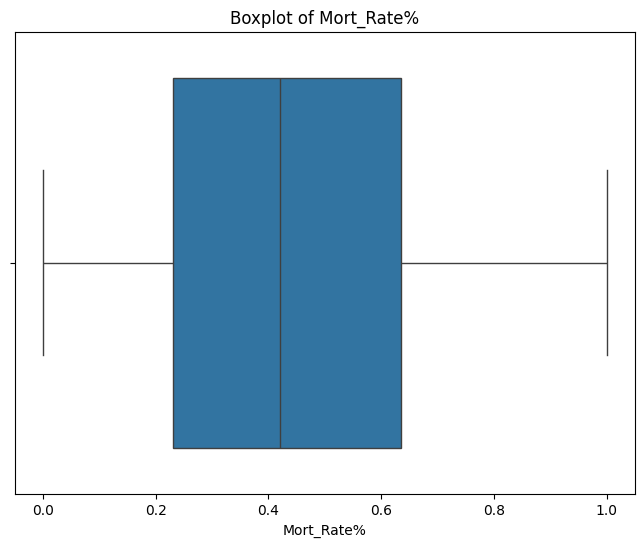

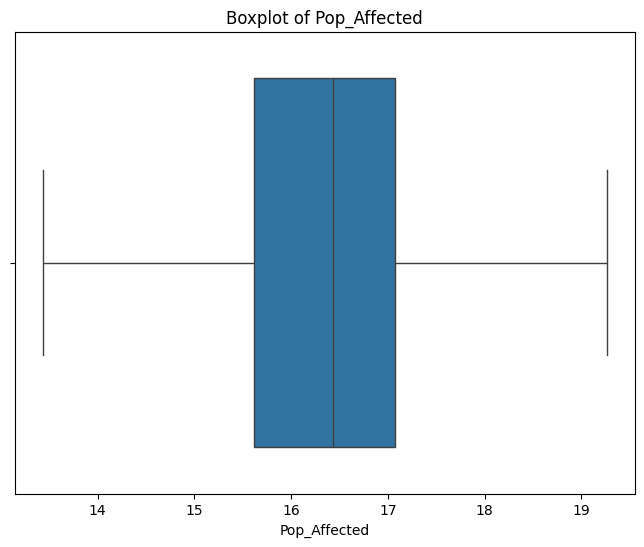

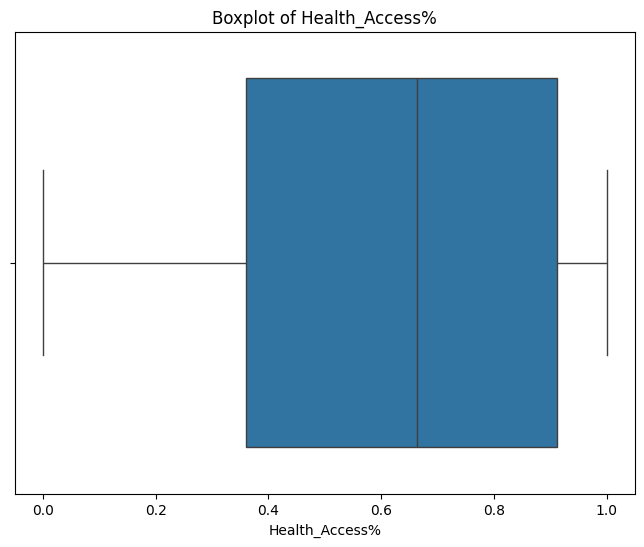

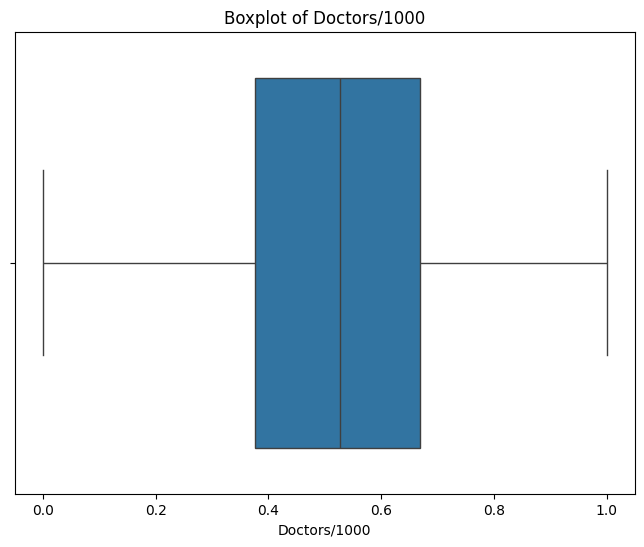

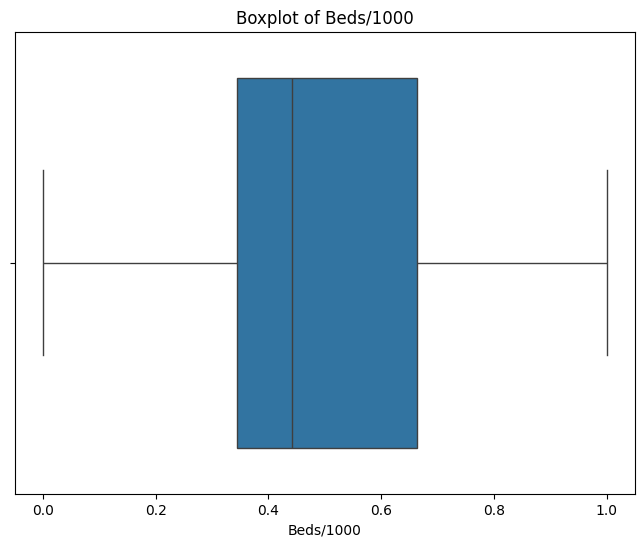

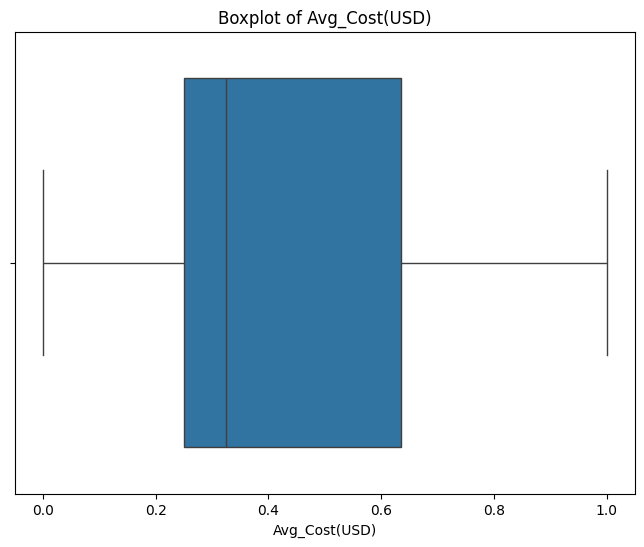

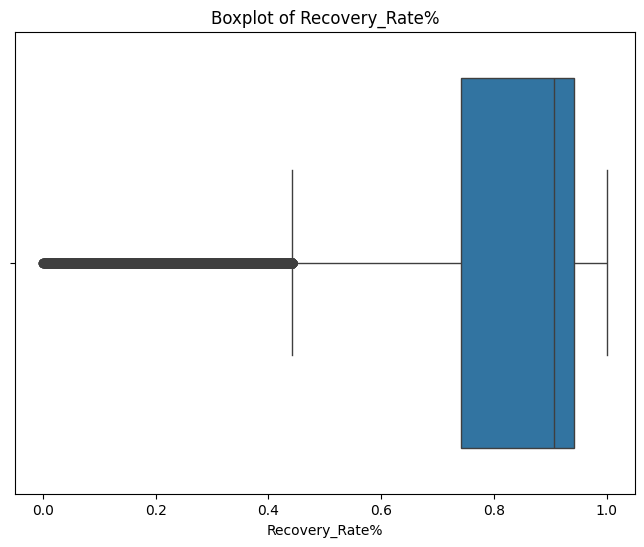

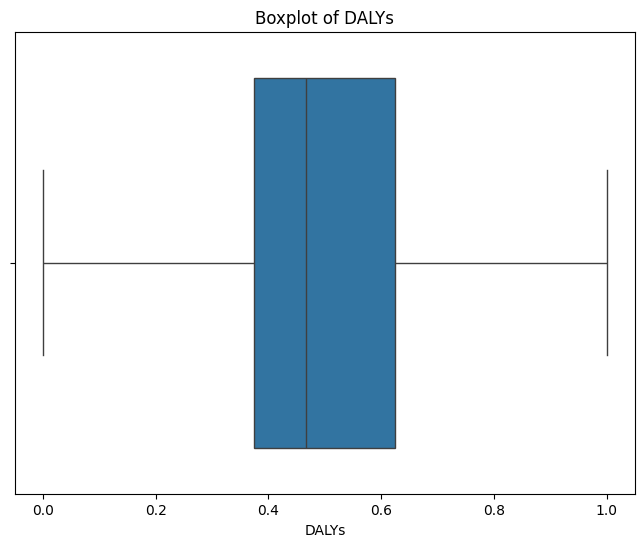

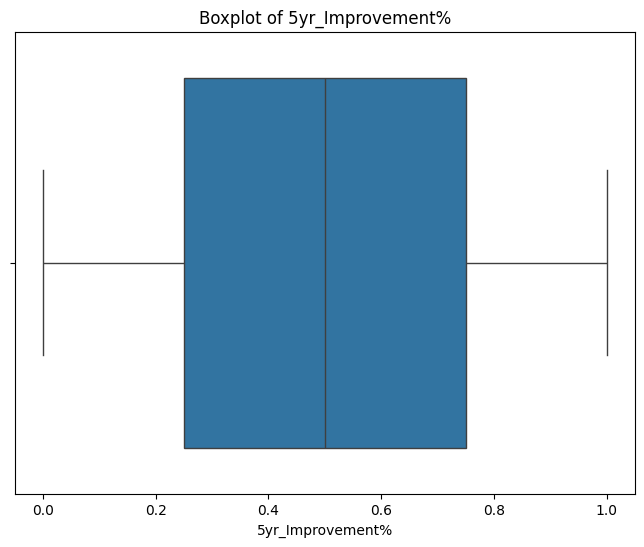

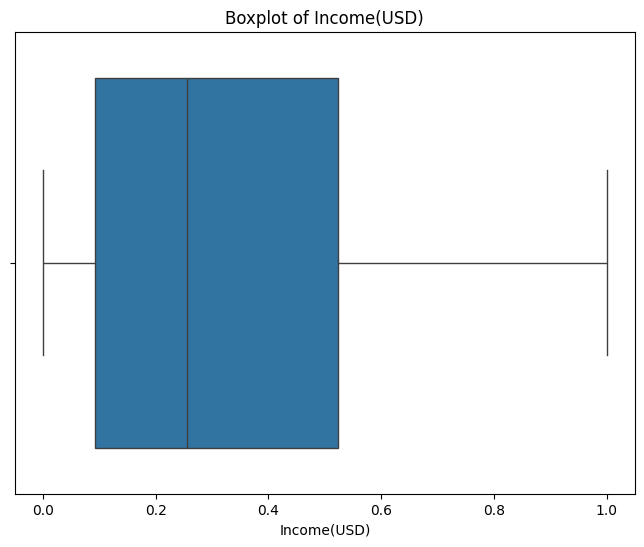

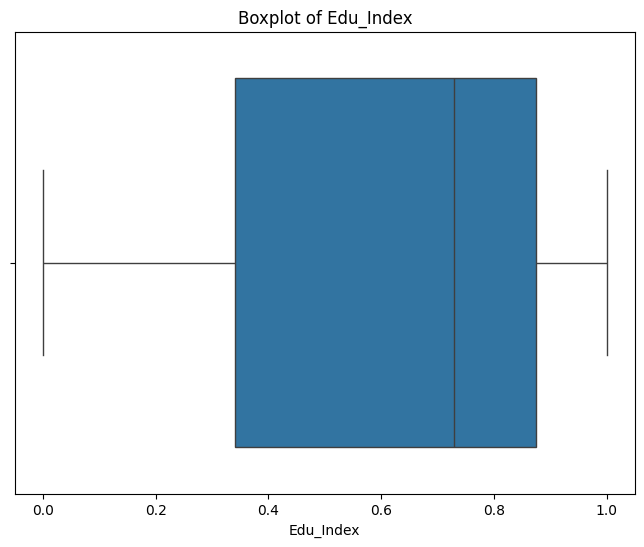

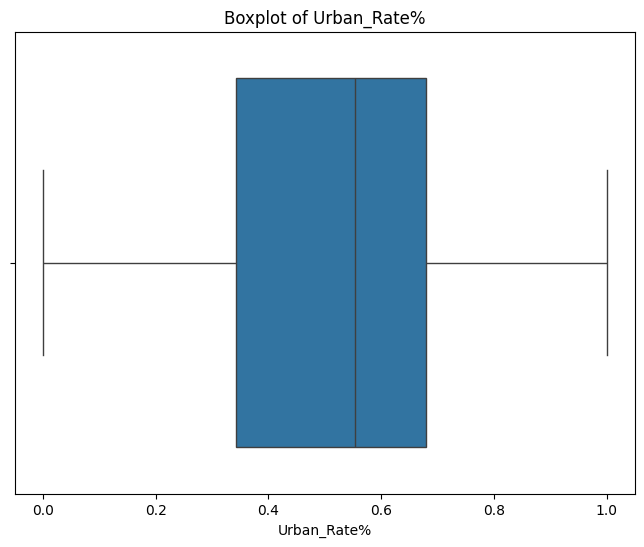

In [61]:
# Step 1: Boxplot for numerical data to check for outliers
numerical_columns = final_df.select_dtypes(include=[float, int]).columns

# Create a boxplot for each numerical variable
for column in numerical_columns:
    plt.figure(figsize=(8, 6))  # Create a new figure for each plot
    sns.boxplot(x=final_df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()  # Show each boxplot separately

##### Check Count of Outliers

In [15]:
# Step 1: Identify numerical columns
numerical_columns = final_df.select_dtypes(include=[float, int]).columns

# Step 2: Count outliers for each numerical column
outliers_count = {}

for column in numerical_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = final_df[column].quantile(0.25)
    Q3 = final_df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers: values below the lower bound or above the upper bound
    outliers = final_df[(final_df[column] < lower_bound) | (final_df[column] > upper_bound)]
    outliers_count[column] = outliers.shape[0]

# Step 3: Print the count of outliers for each numerical column
print("Outliers count for each numerical column:")
for column, count in outliers_count.items():
    print(f"{column}: {count} outliers")

Outliers count for each numerical column:
Year: 0 outliers
Prev_Rate%: 0 outliers
Inc_Rate%: 0 outliers
Mort_Rate%: 0 outliers
Pop_Affected: 0 outliers
Health_Access%: 0 outliers
Doctors/1000: 0 outliers
Beds/1000: 0 outliers
Avg_Cost(USD): 0 outliers
Recovery_Rate%: 15205 outliers
DALYs: 5946 outliers
5yr_Improvement%: 0 outliers
Income(USD): 0 outliers
Edu_Index: 0 outliers
Urban_Rate%: 0 outliers


##### Identify Relationship of Variables between Target Variable

In [63]:
from scipy.stats import pearsonr, spearmanr, f_oneway
import pandas as pd

# Assume df is your DataFrame
# For numerical features: compute Pearson & Spearman correlations with the target variable "Recovery_Rate%"
numerical_features = final_df.select_dtypes(include=[float, int]).columns

numerical_corr_results = {}
for feature in numerical_features:
    if feature != 'Recovery_Rate%':
        # Compute Pearson correlation
        pearson_corr, _ = pearsonr(final_df[feature], final_df['Recovery_Rate%'])
        # Compute Spearman correlation
        spearman_corr, _ = spearmanr(final_df[feature], final_df['Recovery_Rate%'])
        numerical_corr_results[feature] = {
            'Pearson Correlation': pearson_corr,
            'Spearman Correlation': spearman_corr
        }

# For categorical features: compute ANOVA (F-test) to see if Recovery_Rate% differs by groups.
# We include both 'object' and 'category' data types.
categorical_features = final_df.select_dtypes(include=['object', 'category']).columns

categorical_anova_results = {}
for feature in categorical_features:
    if feature != 'Recovery_Rate%':
        unique_vals = final_df[feature].unique()
        if len(unique_vals) > 1:
            # Group the target variable by each unique category
            groups = [final_df[final_df[feature] == val]['Recovery_Rate%'] for val in unique_vals]
            f_stat, p_value = f_oneway(*groups)
            categorical_anova_results[feature] = {
                'F-statistic': f_stat,
                'p-value': p_value,
                'Levels': len(unique_vals)
            }
        else:
            categorical_anova_results[feature] = {
                'F-statistic': None,
                'p-value': None,
                'Reason': 'Only one unique category'
            }

# Print numerical features correlation results
print("Correlation Results (Numerical Features):")
for feature, corrs in numerical_corr_results.items():
    print(f"{feature}: Pearson = {corrs['Pearson Correlation']:.3f}, Spearman = {corrs['Spearman Correlation']:.3f}")

# Print categorical features ANOVA results
print("\nANOVA Results (Categorical Features):")
for feature, stats in categorical_anova_results.items():
    if stats.get('F-statistic') is not None:
        print(f"{feature}: F-statistic = {stats['F-statistic']:.3f}, p-value = {stats['p-value']:.3f}, Levels = {stats['Levels']}")
    else:
        print(f"{feature}: {stats.get('Reason', 'No result')}")


Correlation Results (Numerical Features):
Year: Pearson = 0.183, Spearman = 0.040
Prev_Rate%: Pearson = 0.417, Spearman = 0.125
Inc_Rate%: Pearson = 0.590, Spearman = 0.369
Mort_Rate%: Pearson = 0.088, Spearman = -0.043
Pop_Affected: Pearson = -0.220, Spearman = -0.465
Health_Access%: Pearson = 0.217, Spearman = 0.229
Doctors/1000: Pearson = 0.193, Spearman = 0.198
Beds/1000: Pearson = 0.126, Spearman = 0.175
Avg_Cost(USD): Pearson = -0.769, Spearman = -0.597
DALYs: Pearson = -0.490, Spearman = -0.579
5yr_Improvement%: Pearson = -0.004, Spearman = -0.003
Income(USD): Pearson = 0.213, Spearman = 0.240
Edu_Index: Pearson = 0.093, Spearman = 0.069
Urban_Rate%: Pearson = 0.166, Spearman = 0.155

ANOVA Results (Categorical Features):
Country: F-statistic = 500.404, p-value = 0.000, Levels = 19
Disease_Name: F-statistic = 264081.036, p-value = 0.000, Levels = 4
Disease_Category: Only one unique category
Age: F-statistic = 0.044, p-value = 0.988, Levels = 4
Gender: F-statistic = 8.209, p-valu

##### Correlation Matrix

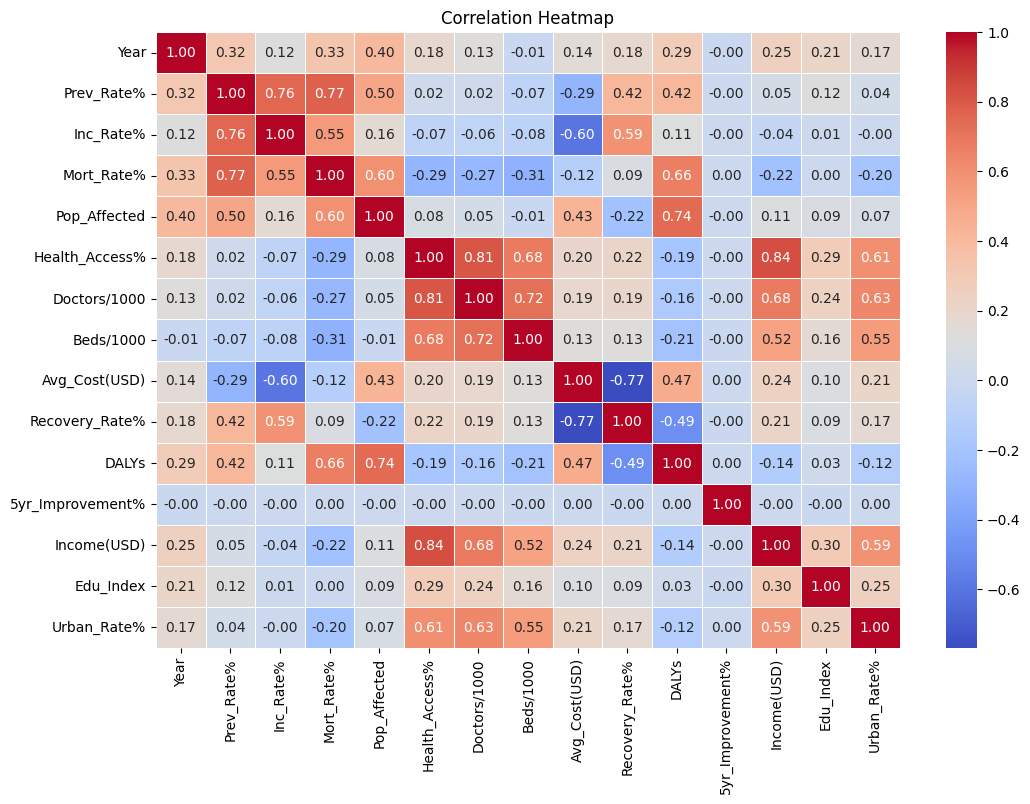

In [64]:
# Filter out non-numeric columns to calculate correlation
numeric_data =final_df.select_dtypes(include=[float, int]) 

# Compute the correlation matrix for numerical features
correlation_matrix = numeric_data.corr()

# Create the heatmap using seaborn
plt.figure(figsize=(12, 8))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# Show the plot
plt.title("Correlation Heatmap")
plt.show()

##### Bar Chart for Category Data

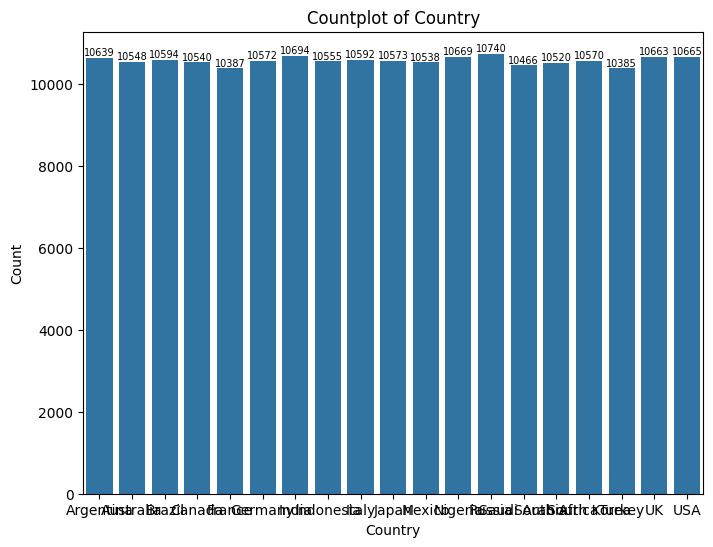

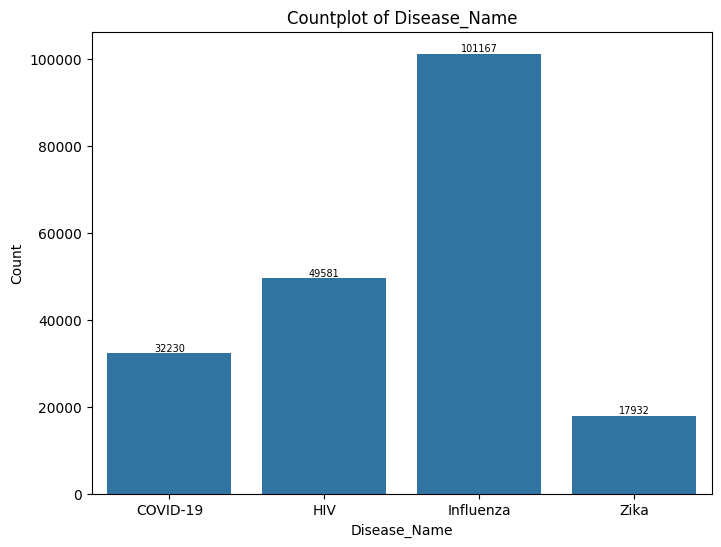

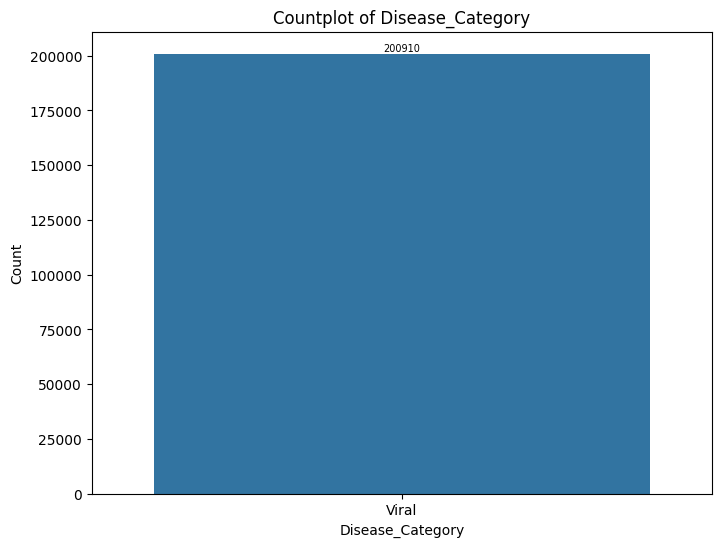

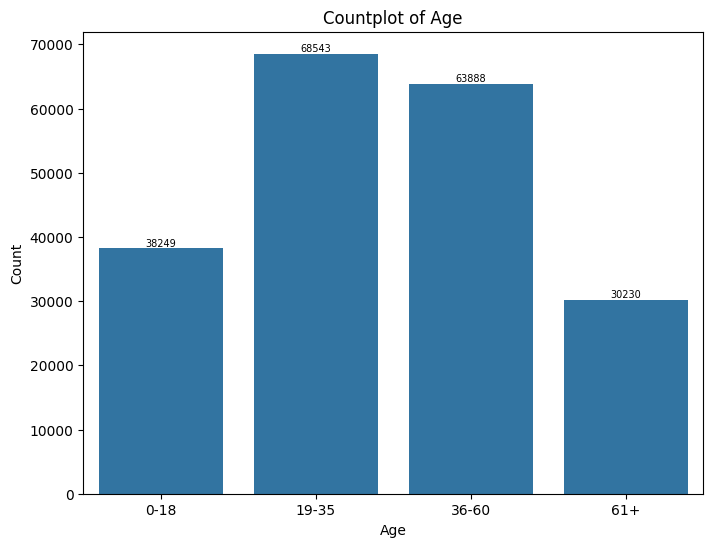

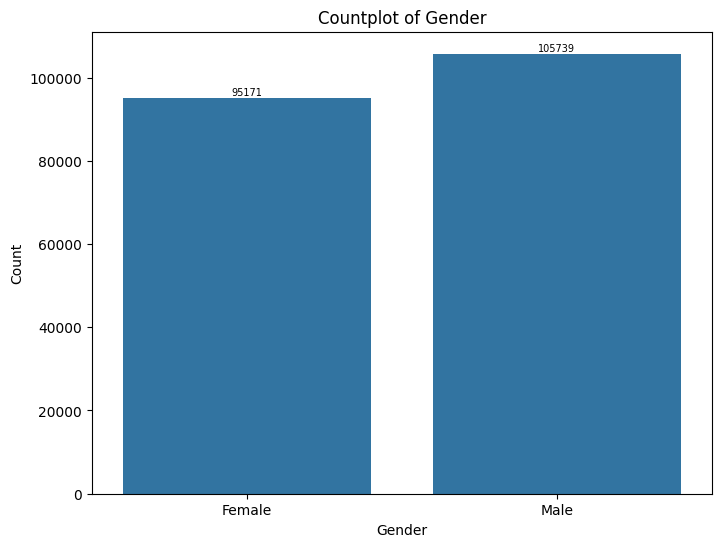

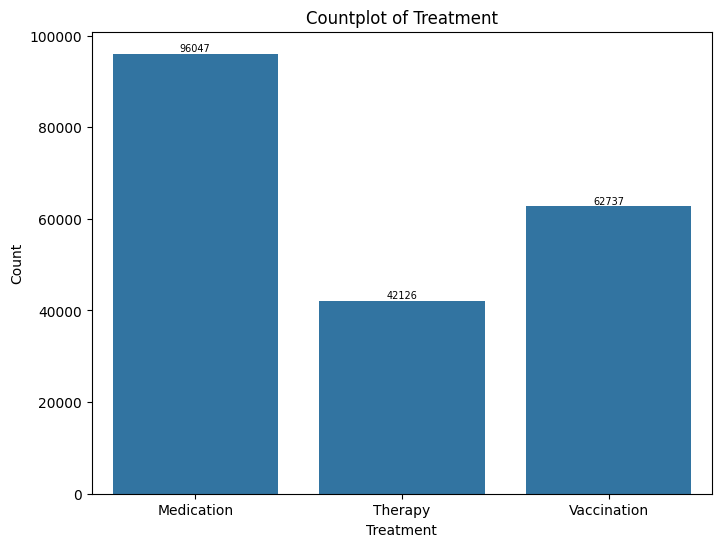

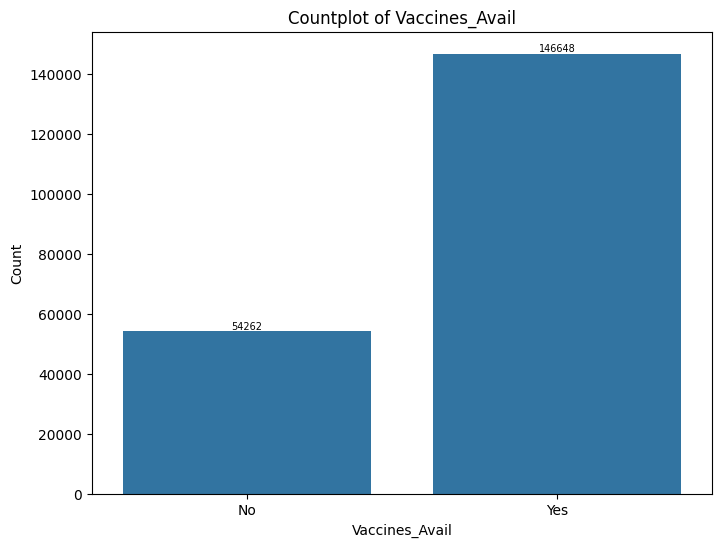

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Categorical data exploration - Countplot for each categorical variable
categorical_columns = final_df.select_dtypes(include=['category']).columns

# Create a countplot for each categorical variable in a separate image
for column in categorical_columns:
    plt.figure(figsize=(8, 6))  # Create a new figure for each categorical variable
    ax = sns.countplot(x=final_df[column])
    
    # Add count annotations on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=7, color='black')

    plt.title(f'Countplot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=0)  # Rotate x labels if needed
    plt.show()  # Show each countplot separately


##### Pie Chart of Categorical Data

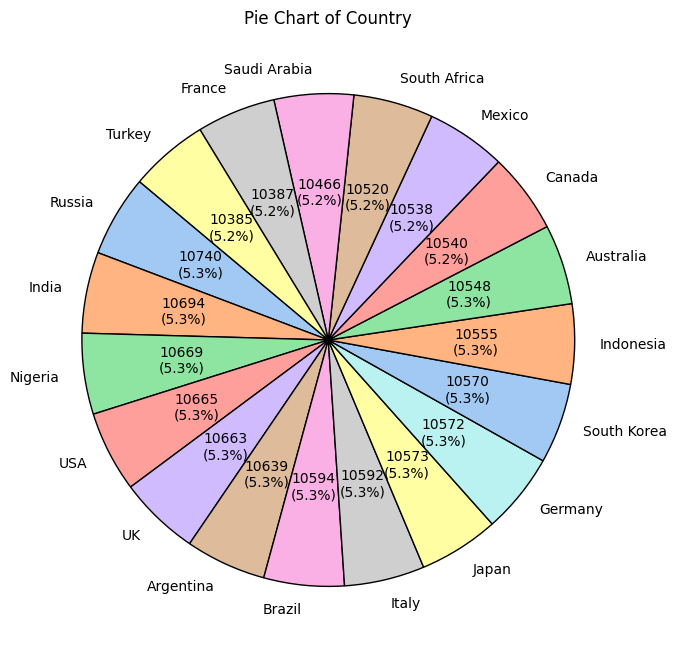

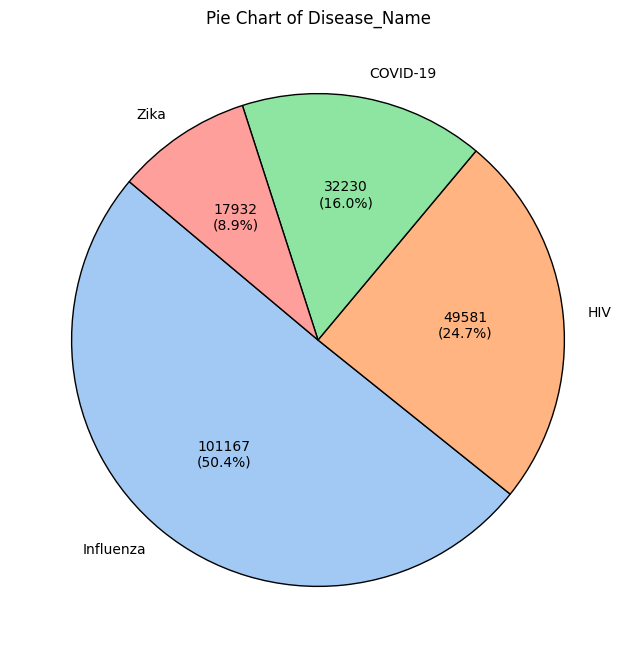

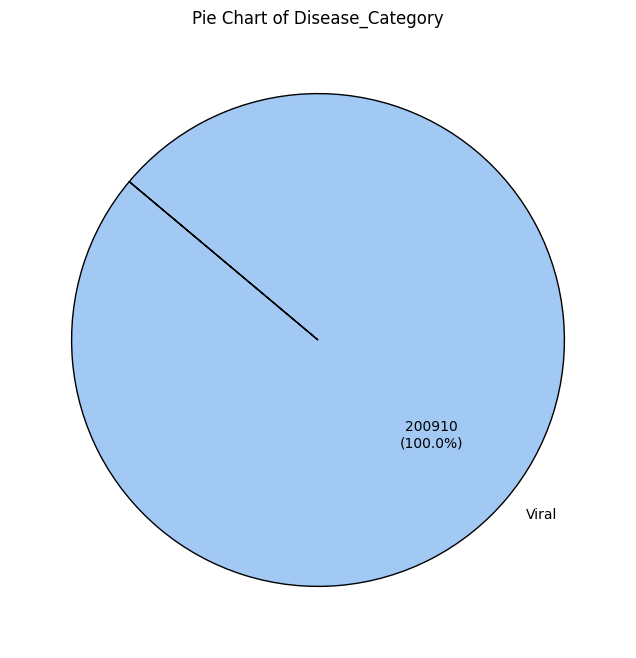

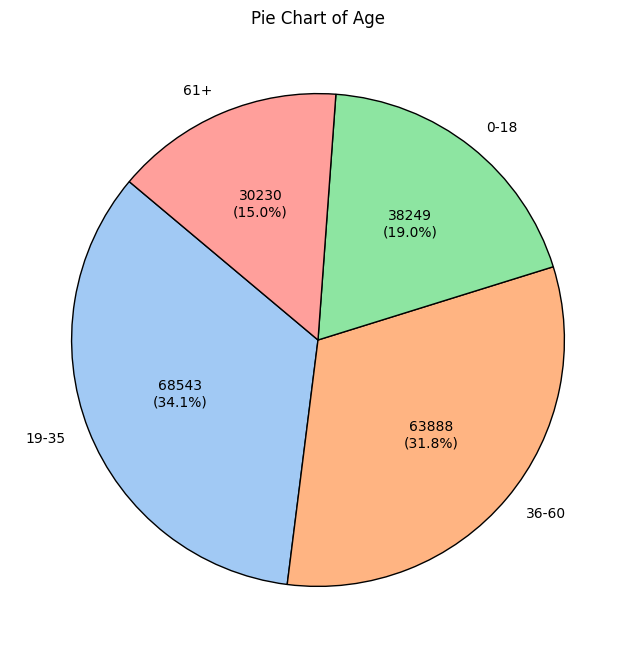

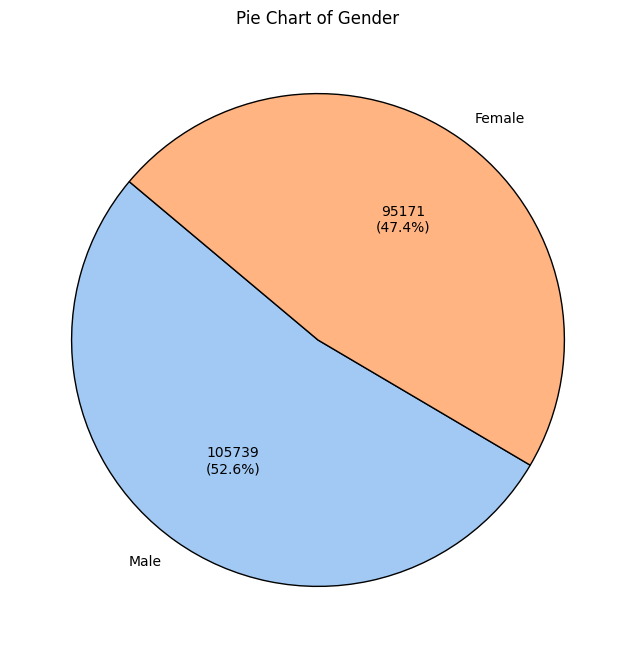

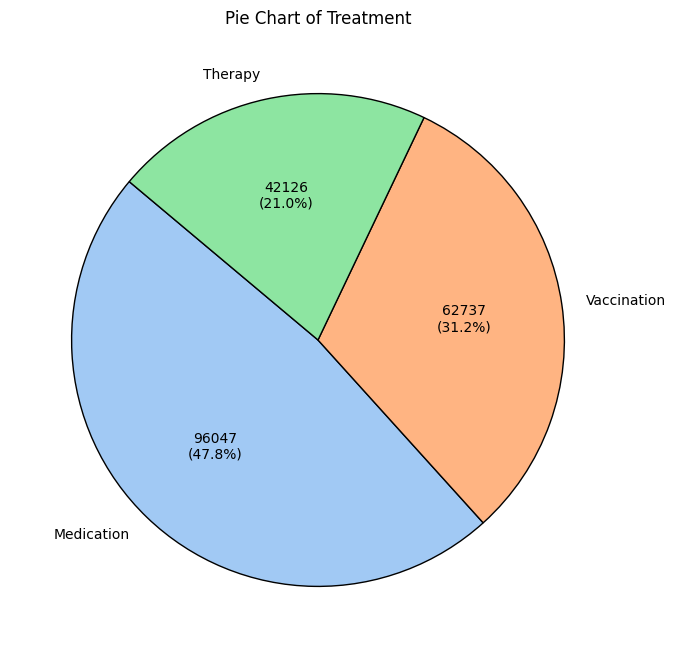

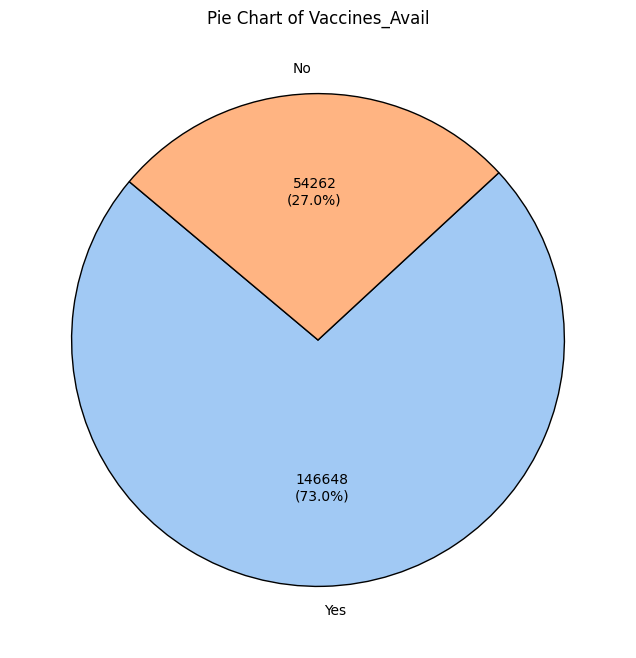

In [66]:
import matplotlib.pyplot as plt

# Step 2: Categorical data exploration - Pie chart for each categorical variable
categorical_columns = final_df.select_dtypes(include=['category']).columns

# Create a pie chart for each categorical variable in a separate image
for column in categorical_columns:
    plt.figure(figsize=(8, 8))  # Create a new figure for each categorical variable
    value_counts = final_df[column].value_counts()  # Get value counts
    
    # Create pie chart with count and percentage labels
    plt.pie(value_counts, labels=value_counts.index, 
            autopct=lambda pct: f'{int(round(pct/100. * sum(value_counts)))}\n({pct:.1f}%)', 
            startangle=140, wedgeprops={'edgecolor': 'black'}, 
            colors=sns.color_palette("pastel"))

    plt.title(f'Pie Chart of {column}')
    plt.show()  # Show each pie chart separately


##### Histogram for Age

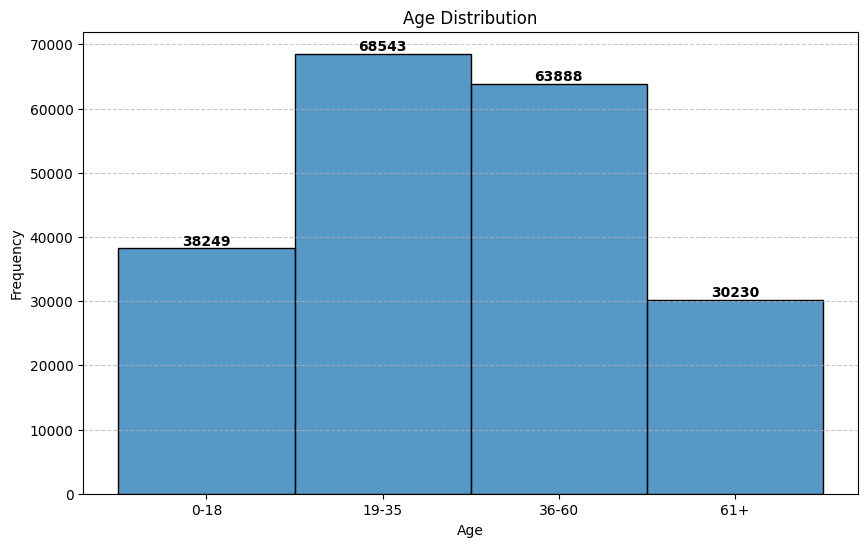

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Plot a histogram for the 'Age' column
plt.figure(figsize=(10, 6))  # Adjust the figure size
ax = sns.histplot(final_df['Age'], bins=30, kde=False)  # Histogram with KDE

# Add count annotations on top of the bars
for p in ax.patches:
    if p.get_height() > 0:  # Only annotate bars with height > 0
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.show()

# Step 2: Print Frequency count for 'Age'


#### Encoding Category Data

In [17]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from tabulate import tabulate

# Back up Data #Drop Disease Category
df_encoded = final_df.drop('Disease_Category', axis=1)

# Ordinal
age_mapping = {'0-18': 0, '19-35': 1, '36-60': 2, '61+': 3}
df_encoded['Age'] = df_encoded['Age'].map(age_mapping)

# Binary
df_encoded['Gender'] = df_encoded['Gender'].map({'Female': 0, 'Male': 1})
df_encoded['Vaccines_Avail'] = df_encoded['Vaccines_Avail'].map({'No': 0, 'Yes': 1})

# Nominal - One-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=['Country'], prefix='Country')
df_encoded = pd.get_dummies(df_encoded, columns=['Disease_Name'], prefix='Disease')

# Display first 5 rows
print(tabulate(df_encoded.head(5), headers='keys', tablefmt='pretty'))

# Convert to category codes
df_encoded['Gender'] = df_encoded['Gender'].astype('category').cat.codes
df_encoded['Treatment'] = df_encoded['Treatment'].astype('category').cat.codes
df_encoded['Vaccines_Avail'] = df_encoded['Vaccines_Avail'].astype('category').cat.codes
df_encoded['Age'] = df_encoded['Age'].astype('category').cat.codes

# Display dataset info
df_encoded.info()
df_encoded.describe()


+---+------+----------------------+--------------------+----------------------+-----+--------+--------------------+----------------------+----------------------+----------------------+-------------+---------------------+----------------+---------------------+----------------------+--------------------+---------------------+---------------------+----------------------+-------------------+-------------------+----------------+----------------+----------------+-----------------+---------------+-------------------+---------------+---------------+----------------+-----------------+----------------+----------------------+----------------------+---------------------+----------------+------------+-------------+------------------+-------------+-------------------+--------------+
|   | Year |      Prev_Rate%      |     Inc_Rate%      |      Mort_Rate%      | Age | Gender |    Pop_Affected    |    Health_Access%    |     Doctors/1000     |      Beds/1000       |  Treatment  |    Avg_Cost(USD)    |

,Year,Prev_Rate%,Inc_Rate%,Mort_Rate%,Age,Gender,Pop_Affected,Health_Access%,Doctors/1000,Beds/1000,Treatment,Avg_Cost(USD),Vaccines_Avail,Recovery_Rate%,DALYs,5yr_Improvement%,Income(USD),Edu_Index,Urban_Rate%
count,200910.000000,2.009100e+05,2.009100e+05,2.009100e+05,200910.000000,200910.000000,200910.000000,2.009100e+05,2.009100e+05,2.009100e+05,200910.000000,2.009100e+05,200910.000000,2.009100e+05,2.009100e+05,2.009100e+05,2.009100e+05,2.009100e+05,2.009100e+05
mean,2013.616077,-3.328669e-16,-9.718637e-17,3.941919e-16,1.428545,0.526300,16.494637,7.564835e-17,2.334171e-17,2.560868e-16,0.834204,2.336823e-16,0.729919,4.449778e-16,-3.371815e-16,4.739074e-17,-2.631600e-16,-1.028803e-16,-5.046052e-16
std,6.913517,1.000002e+00,1.000002e+00,1.000002e+00,0.962594,0.499309,1.515680,1.000002e+00,1.000002e+00,1.000002e+00,0.873407,1.000002e+00,0.444003,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,2000.000000,-1.270599e+00,-1.288425e+00,-1.760790e+00,0.000000,0.000000,13.435750,-1.971148e+00,-2.038446e+00,-1.907725e+00,0.000000,-1.898299e+00,0.000000,-4.142665e+00,-2.043475e+00,-1.708106e+00,-1.290127e+00,-2.052448e+00,-1.947452e+00
25%,2008.000000,-1.169912e+00,-1.276399e+00,-8.689599e-01,1.000000,0.000000,15.621039,-8.121022e-01,-4.864663e-01,-5.513142e-01,0.000000,-7.781048e-01,0.000000,-3.632478e-01,-4.928445e-01,-8.523749e-01,-9.142920e-01,-8.811678e-01,-6.319297e-01
50%,2014.000000,1.193309e-01,2.413169e-01,-1.294427e-01,1.000000,1.000000,16.430755,1.649079e-01,1.323610e-01,-1.599899e-01,1.000000,-4.479352e-01,1.000000,4.724856e-01,-1.129643e-01,3.356524e-03,-2.492670e-01,4.520908e-01,1.837428e-01
75%,2020.000000,5.330267e-01,7.752835e-01,6.978975e-01,2.000000,1.000000,17.077898,9.673560e-01,7.217203e-01,7.150568e-01,2.000000,9.386666e-01,1.000000,6.557856e-01,5.409091e-01,8.590880e-01,8.471173e-01,9.547228e-01,6.722305e-01
max,2024.000000,3.087434e+00,2.319457e+00,2.115565e+00,3.000000,1.000000,19.263187,1.251025e+00,2.087069e+00,2.042212e+00,2.000000,2.567714e+00,1.000000,9.507840e-01,2.091539e+00,1.714819e+00,2.798353e+00,1.382682e+00,1.905182e+00


##### Export Encoded Dataset

In [18]:
# Save the encoded DataFrame to a CSV file
df_encoded.to_csv('fyp_encoded_dataset.csv', index=False)

print("Dataset saved as 'fyp_encoded_dataset.csv'.")

Dataset saved as 'fyp_encoded_dataset.csv'.


#### Import Encoded Dataset

In [19]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns  

# Loading the dataset
dataset_path = "D:/CS DA Y3S2/FYP pt2/Assignment/fyp_encoded_dataset.csv"
df_encoded = pd.read_csv(dataset_path)

# Print out the dataset information (number of rows and columns)
print("Dataset Info:")
print(f"Number of Rows: {df_encoded.shape[0]}")
print(f"Number of Columns: {df_encoded.shape[1]}")

# Display the first few rows of the dataset
print("First few rows of the dataset:\n")
df_encoded.head()
df_encoded.info()
df_encoded.describe()

Dataset Info:
Number of Rows: 200910
Number of Columns: 42
First few rows of the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200910 entries, 0 to 200909
Data columns (total 42 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Year                  200910 non-null  int64  
 1   Prev_Rate%            200910 non-null  float64
 2   Inc_Rate%             200910 non-null  float64
 3   Mort_Rate%            200910 non-null  float64
 4   Age                   200910 non-null  int64  
 5   Gender                200910 non-null  int64  
 6   Pop_Affected          200910 non-null  float64
 7   Health_Access%        200910 non-null  float64
 8   Doctors/1000          200910 non-null  float64
 9   Beds/1000             200910 non-null  float64
 10  Treatment             200910 non-null  int64  
 11  Avg_Cost(USD)         200910 non-null  float64
 12  Vaccines_Avail        200910 non-null  int64  
 13  Recovery_Rate

,Year,Prev_Rate%,Inc_Rate%,Mort_Rate%,Age,Gender,Pop_Affected,Health_Access%,Doctors/1000,Beds/1000,Treatment,Avg_Cost(USD),Vaccines_Avail,Recovery_Rate%,DALYs,5yr_Improvement%,Income(USD),Edu_Index,Urban_Rate%
count,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000,200910.000000
mean,2013.616077,0.291553,0.357114,0.454239,1.428545,0.526300,16.494637,0.611745,0.494107,0.482976,0.834204,0.425055,0.729919,0.813332,0.494188,0.499019,0.315552,0.597488,0.505486
std,6.913517,0.229462,0.277172,0.257975,0.962594,0.499309,1.515680,0.310350,0.242395,0.253169,0.873407,0.223914,0.444003,0.196331,0.241838,0.292148,0.244590,0.291111,0.259563
min,2000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.435750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008.000000,0.023104,0.003333,0.230069,1.000000,0.000000,15.621039,0.359709,0.376190,0.343401,0.000000,0.250827,0.000000,0.742015,0.375000,0.250000,0.091925,0.340971,0.341460
50%,2014.000000,0.318935,0.424000,0.420846,1.000000,1.000000,16.430755,0.662924,0.526190,0.442472,1.000000,0.324756,1.000000,0.906095,0.466869,0.500000,0.254584,0.729096,0.553179
75%,2020.000000,0.413862,0.572000,0.634278,2.000000,1.000000,17.077898,0.911964,0.669048,0.664006,2.000000,0.635234,1.000000,0.942083,0.625000,0.750000,0.522748,0.875417,0.679972
max,2024.000000,1.000000,1.000000,1.000000,3.000000,1.000000,19.263187,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

model_data = df_encoded.copy()

# Define features and target
features = df_encoded.drop(columns=['Recovery_Rate%']).columns.tolist()
target = 'Recovery_Rate%'

# Split the data into training and testing sets
X = model_data[features]
y = model_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train the model
rf_model.fit(X_train, y_train)
# Make predictions
rf_preds = rf_model.predict(X_test)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mse = mean_squared_error(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# Feature importance
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print results
print(f"\nRandom Forest RMSE: {rf_rmse}")
print(f"Random Forest MSE: {rf_mse}")
print(f"Random Forest MAE: {rf_mae}")
print(f"Random Forest R²: {rf_r2}")
print("\nTop Feature Importances:")
print(importance_df)



Random Forest RMSE: 0.037775440400653726
Random Forest MSE: 0.0014269838974633416
Random Forest MAE: 0.0292242935220545
Random Forest R²: 0.9629953670349566

Top Feature Importances:
                 Feature    Importance
38           Disease_HIV  7.727881e-01
15           Income(USD)  8.439524e-02
0                   Year  6.857899e-02
13                 DALYs  2.811681e-02
3             Mort_Rate%  7.335042e-03
1             Prev_Rate%  6.421194e-03
8           Doctors/1000  4.763721e-03
17           Urban_Rate%  4.205752e-03
7         Health_Access%  4.162562e-03
11         Avg_Cost(USD)  3.397761e-03
9              Beds/1000  3.159329e-03
6           Pop_Affected  2.924572e-03
14      5yr_Improvement%  2.811045e-03
2              Inc_Rate%  2.343810e-03
16             Edu_Index  1.478839e-03
4                    Age  8.641408e-04
32  Country_South Africa  5.727168e-04
10             Treatment  4.098453e-04
5                 Gender  3.760375e-04
12        Vaccines_Avail  3.297452e-

#### Feature Selection and Data Partition

In [20]:
from sklearn.model_selection import train_test_split
model_data = df_encoded.copy()

#Feature Selection (Random Forest Feature Importance)
features = ['Income(USD)', 'Year', 'DALYs', 'Mort_Rate%', 'Prev_Rate%', 'Doctors/1000', 'Urban_Rate%', 'Health_Access%', 'Avg_Cost(USD)', 'Beds/1000']\
      + [col for col in model_data.columns if col.startswith('Disease_')] + [col for col in model_data.columns if col.startswith('Country_')] 
target = 'Recovery_Rate%'

# Data Partition (70-30)
X = model_data[features]
y = model_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4.0 Base Model Building

#### XGBoost - Base Model


XGBoost RMSE: 0.03764906542594899
XGBoost MSE: 0.0014174521274473875
XGBoost MAE: 0.029142415024887368
XGBoost R²: 0.9632425454730417
XGBoost Adjusted R²: 0.9632224090830055
XGBoost SMAPE: 4.787690970193884%


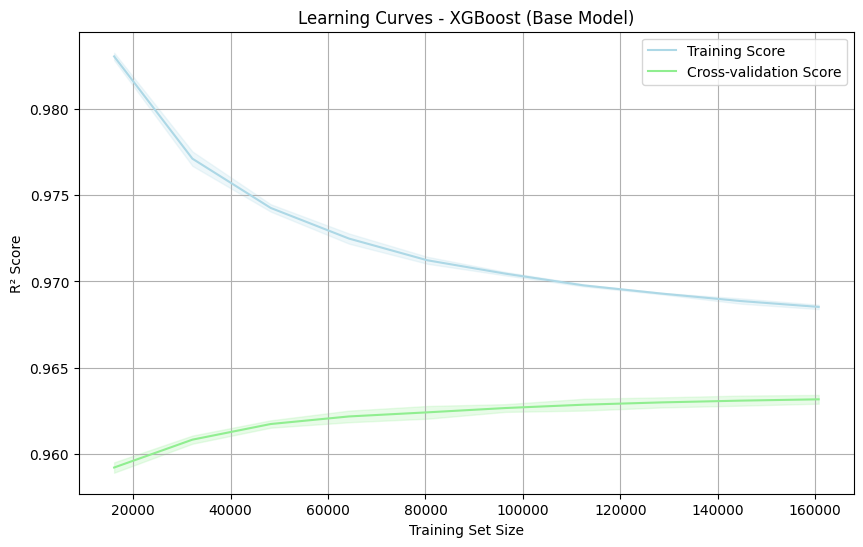

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
# Train XGBoost model
xgb_model.fit(X_train, y_train)
# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Calculate Evaluation Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
smape = np.mean(2 * np.abs(xgb_preds - y_test) / (np.abs(xgb_preds) + np.abs(y_test))) * 100
# Adjusted R² Calculation
n = len(y_test)  # Number of data points
p = X_train.shape[1]  # Number of features
r2_adjusted = 1 - (1 - xgb_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nXGBoost RMSE: {xgb_rmse}")
print(f"XGBoost MSE: {xgb_mse}")
print(f"XGBoost MAE: {xgb_mae}")
print(f"XGBoost R²: {xgb_r2}")
print(f"XGBoost Adjusted R²: {r2_adjusted}")
print(f"XGBoost SMAPE: {smape}%")

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(xgb_model, X, y, cv=5, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="lightblue")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="lightgreen")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightblue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.title('Learning Curves - XGBoost (Base Model)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.show()

#### Decision Tree - Base Model


Decision Tree RMSE: 0.05300751946982074
Decision Tree MSE: 0.0028097971203434246
Decision Tree MAE: 0.0388694160866304
Decision Tree R²: 0.9271361706818311
Decision Tree Adjusted R²: 0.9270962545748654
Decision Tree SMAPE: 6.3637714850037455


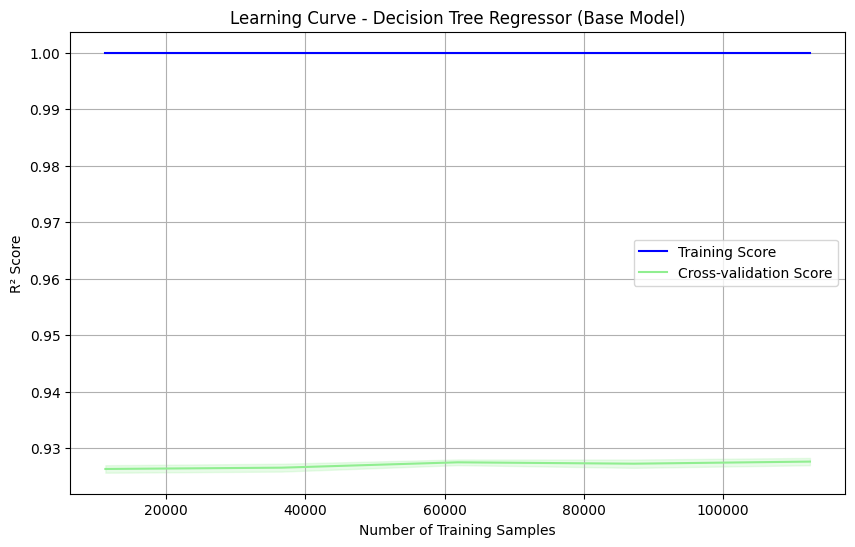

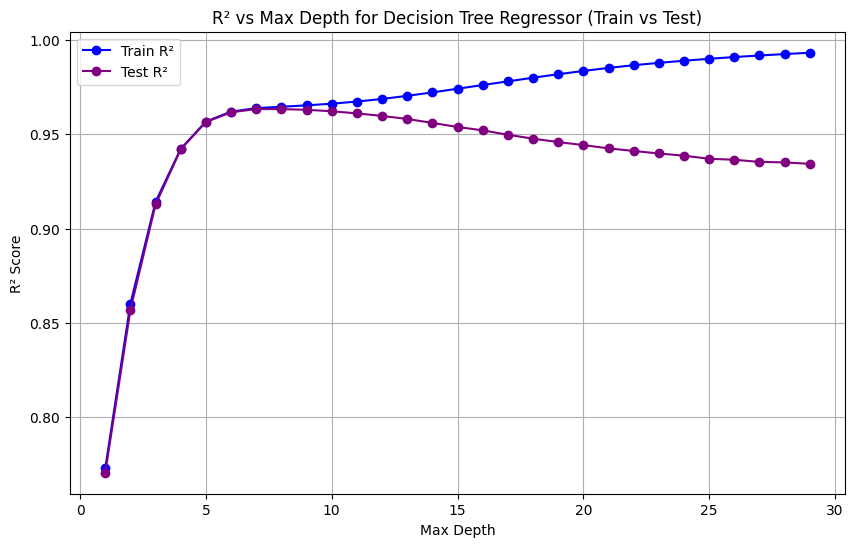

In [4]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Initialize DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
# Fit the model (assuming X_train, y_train, X_test, y_test are defined)
dt_model.fit(X_train, y_train)
# Make predictions
dt_preds = dt_model.predict(X_test)

# Calculate evaluation metrics
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mse = mean_squared_error(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)
dt_smape = np.mean(2 * np.abs(y_test - dt_preds) / (np.abs(y_test) + np.abs(dt_preds))) * 100
# Calculate Adjusted R²
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
dt_r2_adj = 1 - (1 - dt_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nDecision Tree RMSE: {dt_rmse}")
print(f"Decision Tree MSE: {dt_mse}")
print(f"Decision Tree MAE: {dt_mae}")
print(f"Decision Tree R²: {dt_r2}")
print(f"Decision Tree Adjusted R²: {dt_r2_adj}")
print(f"Decision Tree SMAPE: {dt_smape}")

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(dt_model, X_train, y_train, cv=5)
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="blue")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="lightgreen")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightblue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title("Learning Curve - Decision Tree Regressor (Base Model)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# R² vs max_depth (Separate train and test R²)
max_depth_range = range(1, 30) 
train_r2_scores = []
test_r2_scores = []


for depth in max_depth_range:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train, y_train)
    
    # R² for training data
    train_preds = dt_model.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_r2_scores.append(train_r2)
    
    # R² for testing data
    test_preds = dt_model.predict(X_test)
    test_r2 = r2_score(y_test, test_preds)
    test_r2_scores.append(test_r2)

# Plot R² vs max_depth for both training and testing data
plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, train_r2_scores, marker='o', label='Train R²', color='blue')
plt.plot(max_depth_range, test_r2_scores, marker='o', label='Test R²', color='purple')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('R² vs Max Depth for Decision Tree Regressor (Train vs Test)')
plt.legend(loc="best")
plt.grid(True)
plt.show()

#### Linear Regression - Base Model


Linear Regression RMSE: 0.0617170450577637
Linear Regression MSE: 0.003808993650662035
Linear Regression MAE: 0.04755224210839976
Linear Regression R²: 0.9012249456637261
Linear Regression Adjusted R²: 0.9011708349249506
Linear Regression SMAPE: 7.296256756213528


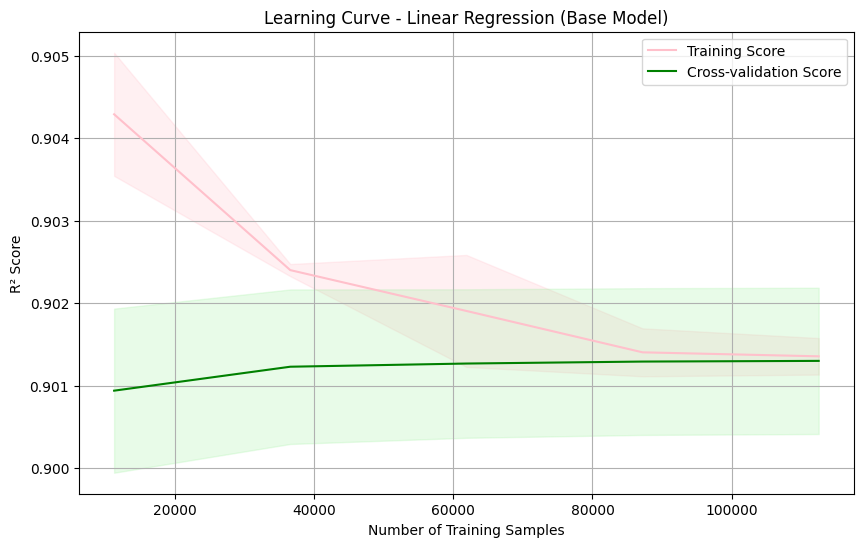

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Initialize Linear Regression model
linreg_model = LinearRegression()
# Fit the model (assuming X_train and y_train are already defined)
linreg_model.fit(X_train, y_train)
# Make predictions
linreg_preds = linreg_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, linreg_preds)
mae = mean_absolute_error(y_test, linreg_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linreg_preds)
smape = np.mean(2 * np.abs(y_test - linreg_preds) / (np.abs(y_test) + np.abs(linreg_preds))) * 100
# Calculate Adjusted R²
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nLinear Regression RMSE: {rmse}")
print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression MAE: {mae}")
print(f"Linear Regression R²: {r2}")
print(f"Linear Regression Adjusted R²: {r2_adj}")
print(f"Linear Regression SMAPE: {smape}")

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(linreg_model, X_train, y_train, cv=5)
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="pink")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="green")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightpink")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title("Learning Curve - Linear Regression (Base Model)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

#### Bayesian Ridge Regression - Base Model


Bayesian Regression RMSE: 0.061717000396792204
Bayesian Regression  MSE: 0.0038089881379776494
Bayesian Regression  MAE: 0.0475510865879055
Bayesian Regression  R²: 0.9012250886189919
Bayesian Regression  Adjusted R²: 0.9011709779585299
Bayesian Regression  SMAPE: 7.2962779151895685


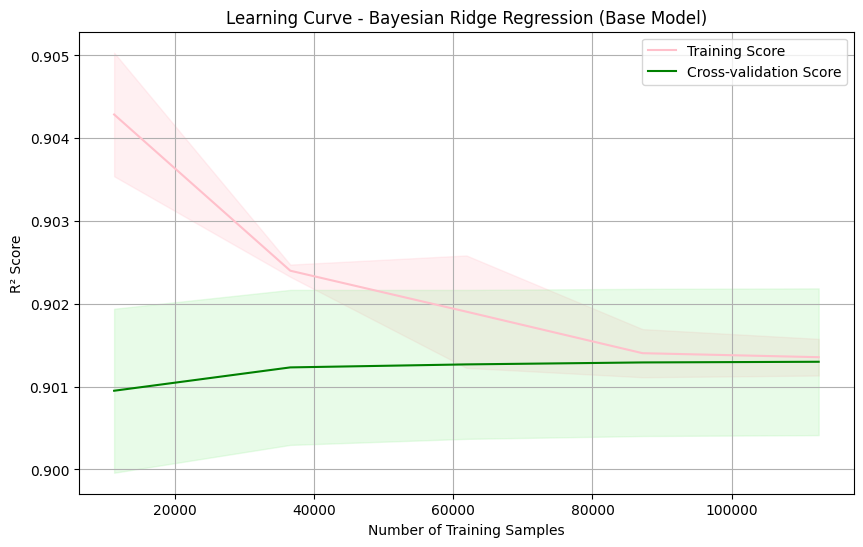

In [22]:
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Initialize Bayesian Ridge Regression model
bayesian_ridge_model = BayesianRidge()
# Train the model
bayesian_ridge_model.fit(X_train, y_train)
# Make predictions
preds = bayesian_ridge_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
smape = np.mean(2 * np.abs(y_test - preds) / (np.abs(y_test) + np.abs(preds))) * 100
# Calculate Adjusted R²
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nBayesian Regression RMSE: {rmse}")
print(f"Bayesian Regression  MSE: {mse}")
print(f"Bayesian Regression  MAE: {mae}")
print(f"Bayesian Regression  R²: {r2}")
print(f"Bayesian Regression  Adjusted R²: {r2_adj}")
print(f"Bayesian Regression  SMAPE: {smape}")

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(bayesian_ridge_model, X_train, y_train, cv=5)
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="pink")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="green")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightpink")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title("Learning Curve - Bayesian Ridge Regression (Base Model)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### 5.0 Hyperparameter Tuning

#### XGBoost (Optuna Tune)

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to define the model and objective for Optuna Hyperband optimization
def objective(trial):
    # Hyperparameter space to explore
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01),
        'max_depth': trial.suggest_int('max_depth', 3, 12, step=1),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0, step=0.1),
        'gamma': trial.suggest_float('gamma', 0, 0.5, step=0.1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'lambda': trial.suggest_float('lambda', 0, 1, step=0.1),  # L2 regularization
        'alpha': trial.suggest_float('alpha', 0, 1, step=0.1),    # L1 regularization
    }   
    # Initialize XGBoost Regressor with parameters from the trial
    model = xgb.XGBRegressor(**param, random_state=42, early_stopping_rounds=30)
    # Train the model with early stopping
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    # Make predictions
    preds = model.predict(X_test)
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

# Create Optuna study 
study = optuna.create_study(direction='minimize')
# Perform optimization with early stopping and Hyperband
study.optimize(objective, n_trials=200, timeout=360000) 
# Print best hyperparameters found by Optuna
print(f"Best Parameters: {study.best_params}")
# Create the best model using the best parameters
best_model = xgb.XGBRegressor(**study.best_params, random_state=42, early_stopping_rounds=30)
# Train the best model
best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
# Make predictions with the best model
xgb_preds = best_model.predict(X_test)

# Calculate performance metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

# Calculate Adjusted R²
n = len(y_test)  # Number of data points
p = X_train.shape[1]  # Number of features
xgb_r2_adj = 1 - (1 - xgb_r2) * (n - 1) / (n - p - 1)

# Calculate SMAPE with a small epsilon to avoid division by zero
epsilon = 1e-10
smape = 100 * np.mean(2 * np.abs(xgb_preds - y_test) / (np.abs(xgb_preds) + np.abs(y_test) + epsilon))

# Print results
print(f"\nXGBoost RMSE: {xgb_rmse}")
print(f"XGBoost MSE: {xgb_mse}")
print(f"XGBoost MAE: {xgb_mae}")
print(f"XGBoost R²: {xgb_r2}")
print(f"XGBoost Adjusted R²: {xgb_r2_adj}")
print(f"XGBoost SMAPE: {smape}")

[I 2025-07-14 09:49:04,448] A new study created in memory with name: no-name-184077c1-15d6-402e-8e37-760115a17776
[I 2025-07-14 09:49:09,425] Trial 0 finished with value: 0.03750642407724238 and parameters: {'n_estimators': 950, 'learning_rate': 0.02, 'max_depth': 7, 'subsample': 0.7999999999999999, 'colsample_bytree': 0.9, 'gamma': 0.1, 'min_child_weight': 2, 'lambda': 0.30000000000000004, 'alpha': 0.4}. Best is trial 0 with value: 0.03750642407724238.
[I 2025-07-14 09:49:18,253] Trial 1 finished with value: 0.03754512507321244 and parameters: {'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 0.7, 'colsample_bytree': 0.9, 'gamma': 0.1, 'min_child_weight': 3, 'lambda': 0.8, 'alpha': 0.4}. Best is trial 0 with value: 0.03750642407724238.
[I 2025-07-14 09:49:22,909] Trial 2 finished with value: 0.03750195182804718 and parameters: {'n_estimators': 1000, 'learning_rate': 0.02, 'max_depth': 7, 'subsample': 0.8999999999999999, 'colsample_bytree': 1.0, 'gamma': 0.1, '

Best Parameters: {'n_estimators': 900, 'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.7999999999999999, 'colsample_bytree': 1.0, 'gamma': 0.0, 'min_child_weight': 3, 'lambda': 0.30000000000000004, 'alpha': 0.5}

XGBoost RMSE: 0.037215365621663665
XGBoost MSE: 0.0013849834383541058
XGBoost MAE: 0.028954882203700523
XGBoost R²: 0.9640845254875946
XGBoost Adjusted R²: 0.9640648503492472
XGBoost SMAPE: 4.738740028991518


#### Decision Tree (GridSearchCV)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# Initialize DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)

# Define the parameter grid 
param_grid = {
   'max_depth': [3, 5, 10, 15, 20, None],
   'min_samples_split': [2, 5, 10, 20],
   'min_samples_leaf': [1, 2, 4, 10],
   'max_features': ['auto', 'sqrt', 'log2', None],
   'criterion': ['mse', 'friedman_mse', 'mae'],
   'max_leaf_nodes': [None, 10, 20, 50],
   'splitter': ['best', 'random'],
   'ccp_alpha': [0.0, 0.01, 0.05]  # Cost-complexity pruning
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best Parameters: {best_params}")

# Make predictions using the best model
dt_preds = best_model.predict(X_test)

# Calculate Evaluation Metrics
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mse = mean_squared_error(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)


# Print results
print(f"\nDecision Tree RMSE: {dt_rmse}")
print(f"Decision Tree MSE: {dt_mse}")
print(f"Decision Tree MAE: {dt_mae}")
print(f"Decision Tree R²: {dt_r2}")


C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
103680 fits failed out of a total of 138240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5733 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\

Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'splitter': 'random'}

Decision Tree RMSE: 0.037986440756120614

Decision Tree MSE: 0.001442969681318261

Decision Tree MAE: 0.029361828870842387

Decision Tree R²: 0.9625808227186112


#### Linear Ridge Regression (Optuna Tune)

In [24]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

# Scale the features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Define the optimization objective function for Hyperband
def objective(trial):
    # Define the hyperparameters to optimize using suggest_float with log=True
    alpha = trial.suggest_float('alpha', 1e-6, 1e+3, log=True)  # Ridge regularization strength
    
    # Initialize the Ridge Regression model with trial hyperparameters
    model = Ridge(alpha=alpha)

    # Use cross-validation to evaluate the model
    cv_scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
    
    # Calculate mean RMSE across folds
    rmse = np.sqrt(-cv_scores.mean())  # We negate because cross_val_score returns negative MSE
    return rmse

# Initialize the Optuna study
study = optuna.create_study(direction='minimize')
# Optimize the model's hyperparameters using Hyperband (TPE)
study.optimize(objective, n_trials=10)
# Get the best trial results
best_trial = study.best_trial
print(f"Best Parameters: {best_trial.params}")

# Train the best model with the optimized parameters
best_model = Ridge(alpha=best_trial.params['alpha'])
# Fit the best model
best_model.fit(X_train_poly, y_train)
# Make predictions with the best model
ridge_preds_optuna = best_model.predict(X_test_poly)

# Calculate evaluation metrics
mse_optuna = mean_squared_error(y_test, ridge_preds_optuna)
mae_optuna = mean_absolute_error(y_test, ridge_preds_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, ridge_preds_optuna)

# Calculate Adjusted R²
n = len(y_test)  # Number of data points
p = X_train_poly.shape[1]  # Number of features
r2_adjusted_optuna = 1 - (1 - r2_optuna) * (n - 1) / (n - p - 1)

# Print results
print(f"Linear Ridge Regression RMSE: {rmse_optuna}")
print(f"Linear Ridge Regression MSE: {mse_optuna}")
print(f"Linear Ridge Regression MAE: {mae_optuna}")
print(f"Linear Ridge Regression R²: {r2_optuna}")
print(f"Linear Ridge Regression Adjusted R²: {r2_adjusted_optuna}")


[I 2025-07-27 22:36:07,455] A new study created in memory with name: no-name-9507823a-d065-4769-8908-d04c145779bb
[I 2025-07-27 22:36:17,385] Trial 0 finished with value: 0.03948519311359147 and parameters: {'alpha': 0.012964404001964809}. Best is trial 0 with value: 0.03948519311359147.
[I 2025-07-27 22:36:24,651] Trial 1 finished with value: 0.039484515045517796 and parameters: {'alpha': 1.183383686521046}. Best is trial 1 with value: 0.039484515045517796.
[I 2025-07-27 22:36:31,799] Trial 2 finished with value: 0.039611557714134944 and parameters: {'alpha': 311.9118571500584}. Best is trial 1 with value: 0.039484515045517796.
[I 2025-07-27 22:36:39,317] Trial 3 finished with value: 0.039491298955376584 and parameters: {'alpha': 14.60426668717665}. Best is trial 1 with value: 0.039484515045517796.
[I 2025-07-27 22:36:46,480] Trial 4 finished with value: 0.039485203106211925 and parameters: {'alpha': 0.004733284157172772}. Best is trial 1 with value: 0.039484515045517796.
[I 2025-07-2

Best Parameters: {'alpha': 1.183383686521046}
Linear Ridge Regression RMSE: 0.039449132810359756
Linear Ridge Regression MSE: 0.0015562340794894026
Linear Ridge Regression MAE: 0.0303283971274993
Linear Ridge Regression R²: 0.9596436434765887
Linear Ridge Regression Adjusted R²: 0.95924195984485


In [ ]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

# Add Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define the optimization objective function for Hyperband
def objective(trial):
    # Define the hyperparameters to optimize using suggest_float with log=True
    alpha = trial.suggest_float('alpha', 1e-6, 1e+3, log=True)  # Ridge regularization strength
    
    # Initialize the Ridge Regression model with trial hyperparameters
    model = Ridge(alpha=alpha)

    # Use cross-validation to evaluate the model
    cv_scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
    
    # Calculate mean RMSE across folds
    rmse = np.sqrt(-cv_scores.mean())  # We negate because cross_val_score returns negative MSE
    return rmse

# Initialize the Optuna study
study = optuna.create_study(direction='minimize')
# Optimize the model's hyperparameters using Hyperband (TPE)
study.optimize(objective, n_trials=100)
# Get the best trial results
best_trial = study.best_trial
print(f"Best Parameters: {best_trial.params}")

# Train the best model with the optimized parameters
best_model = Ridge(alpha=best_trial.params['alpha'])
# Fit the best model
best_model.fit(X_train_poly, y_train)
# Make predictions with the best model
ridge_preds_optuna = best_model.predict(X_test_poly)

# Calculate evaluation metrics
mse_optuna = mean_squared_error(y_test, ridge_preds_optuna)
mae_optuna = mean_absolute_error(y_test, ridge_preds_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, ridge_preds_optuna)

# Calculate Adjusted R²
n = len(y_test)  # Number of data points
p = X_train_poly.shape[1]  # Number of features
r2_adjusted_optuna = 1 - (1 - r2_optuna) * (n - 1) / (n - p - 1)

# Print results
print(f"Linear Ridge Regression RMSE: {rmse_optuna}")
print(f"Linear Ridge Regression MSE: {mse_optuna}")
print(f"Linear Ridge Regression MAE: {mae_optuna}")
print(f"Linear Ridge Regression R²: {r2_optuna}")
print(f"Linear Ridge Regression Adjusted R²: {r2_adjusted_optuna}")


[I 2025-06-24 14:59:53,449] A new study created in memory with name: no-name-ff1794a0-0b41-4625-99a2-34437a31c5ce
C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.77656e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.57371e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\limju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.80244e-19)

Best Parameters from Hyperband: {'alpha': 6.21255072337672e-05}
Linear Ridge Regression RMSE: 0.03922961408062651
Linear Ridge Regression MSE: 0.0015389626209148897
Linear Ridge Regression MAE: 0.030211501855805973
Linear Ridge Regression R²: 0.9600915279877292
Linear Ridge Regression Adjusted R²: 0.9594852042256429


#### Bayesian Ridge Regression (Optuna Tune)

In [25]:
import optuna
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Scale the features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Define the optimization objective function for Hyperband
def objective(trial):
    # Define the hyperparameters to optimize using suggest_float with log=True
    alpha_1 = trial.suggest_float('alpha_1', 1e-6, 1e-1, log=True)
    alpha_2 = trial.suggest_float('alpha_2', 1e-6, 1e-1, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-6, 1e-1, log=True)
    lambda_2 = trial.suggest_float('lambda_2', 1e-6, 1e-1, log=True)

    # Initialize the Bayesian Ridge model with trial hyperparameters
    model = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2, lambda_1=lambda_1, lambda_2=lambda_2)

    # Train the model with cross-validation
    cv_scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
    
    # Calculate mean RMSE across folds
    rmse = np.sqrt(-cv_scores.mean())
    return rmse

# Initialize the Optuna study
study = optuna.create_study(direction='minimize')

# Optimize the model's hyperparameters 
study.optimize(objective, n_trials=10)

# Get the best trial results
best_trial = study.best_trial
print(f"Best Parameters from Bayesian Optimization: {best_trial.params}")

# Train the best model with the optimized parameters
best_model = BayesianRidge(
    alpha_1=best_trial.params['alpha_1'],
    alpha_2=best_trial.params['alpha_2'],
    lambda_1=best_trial.params['lambda_1'],
    lambda_2=best_trial.params['lambda_2']
)

# Fit the best model to the polynomial features
best_model.fit(X_train_poly, y_train)

# Make predictions with the best model
bayesian_ridge_preds_optuna = best_model.predict(X_test_poly)

# Calculate evaluation metrics
mse_optuna = mean_squared_error(y_test, bayesian_ridge_preds_optuna)
mae_optuna = mean_absolute_error(y_test, bayesian_ridge_preds_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, bayesian_ridge_preds_optuna)

# Print results
print(f"\nBayesian Regression RMSE: {rmse_optuna}")
print(f"\nBayesian Regression MSE: {mse_optuna}")
print(f"\nBayesian Regression MAE: {mae_optuna}")
print(f"\nBayesian Regression R²: {r2_optuna}")


[I 2025-07-27 22:37:29,457] A new study created in memory with name: no-name-0d44d111-e9b4-45e7-8006-5e75f37fd752
[I 2025-07-27 22:38:32,875] Trial 0 finished with value: 0.039485512399044936 and parameters: {'alpha_1': 0.027428733094359947, 'alpha_2': 9.419508818384812e-05, 'lambda_1': 4.4547127804755e-06, 'lambda_2': 0.03622680494252336}. Best is trial 0 with value: 0.039485512399044936.
[I 2025-07-27 22:39:36,538] Trial 1 finished with value: 0.03949196851239312 and parameters: {'alpha_1': 6.887924082587997e-05, 'alpha_2': 6.316418370284477e-05, 'lambda_1': 0.027349110676343446, 'lambda_2': 0.001359044183561582}. Best is trial 0 with value: 0.039485512399044936.
[I 2025-07-27 22:40:46,196] Trial 2 finished with value: 0.03948628417462585 and parameters: {'alpha_1': 0.012570279088158248, 'alpha_2': 0.0002933477585632512, 'lambda_1': 0.00044983365637406254, 'lambda_2': 0.023974682042224752}. Best is trial 0 with value: 0.039485512399044936.
[I 2025-07-27 22:41:56,133] Trial 3 finished

Best Parameters from Bayesian Optimization: {'alpha_1': 0.027428733094359947, 'alpha_2': 9.419508818384812e-05, 'lambda_1': 4.4547127804755e-06, 'lambda_2': 0.03622680494252336}

Bayesian Regression RMSE: 0.03945074372616825

Bayesian Regression MSE: 0.0015563611805478033

Bayesian Regression MAE: 0.030325388289038482

Bayesian Regression R²: 0.9596403474842345


In [22]:
import optuna
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Feature Engineering: Adding Polynomial Features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define the optimization objective function for Hyperband
def objective(trial):
    # Define the hyperparameters to optimize using suggest_float with log=True
    alpha_1 = trial.suggest_float('alpha_1', 1e-6, 1e-1, log=True)
    alpha_2 = trial.suggest_float('alpha_2', 1e-6, 1e-1, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-6, 1e-1, log=True)
    lambda_2 = trial.suggest_float('lambda_2', 1e-6, 1e-1, log=True)

    # Initialize the Bayesian Ridge model with trial hyperparameters
    model = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2, lambda_1=lambda_1, lambda_2=lambda_2)

    # Train the model with cross-validation
    cv_scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
    
    # Calculate mean RMSE across folds
    rmse = np.sqrt(-cv_scores.mean())
    return rmse

# Initialize the Optuna study
study = optuna.create_study(direction='minimize')

# Optimize the model's hyperparameters 
study.optimize(objective, n_trials=100)

# Get the best trial results
best_trial = study.best_trial
print(f"Best Parameters from Bayesian Optimization: {best_trial.params}")

# Train the best model with the optimized parameters
best_model = BayesianRidge(
    alpha_1=best_trial.params['alpha_1'],
    alpha_2=best_trial.params['alpha_2'],
    lambda_1=best_trial.params['lambda_1'],
    lambda_2=best_trial.params['lambda_2']
)

# Fit the best model to the polynomial features
best_model.fit(X_train_poly, y_train)

# Make predictions with the best model
bayesian_ridge_preds_optuna = best_model.predict(X_test_poly)

# Calculate evaluation metrics
mse_optuna = mean_squared_error(y_test, bayesian_ridge_preds_optuna)
mae_optuna = mean_absolute_error(y_test, bayesian_ridge_preds_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, bayesian_ridge_preds_optuna)

# Print results
print(f"\nBayesian Regression RMSE: {rmse_optuna}")
print(f"\nBayesian Regression MSE: {mse_optuna}")
print(f"\nBayesian Regression MAE: {mae_optuna}")
print(f"\nBayesian Regression R²: {r2_optuna}")


[I 2025-07-13 16:14:25,943] A new study created in memory with name: no-name-665d9ca8-7678-4c18-ab19-544e6f8c94a9
[I 2025-07-13 16:15:31,742] Trial 0 finished with value: 0.03948888043055849 and parameters: {'alpha_1': 4.1365824287987857e-05, 'alpha_2': 0.0003792247981553867, 'lambda_1': 0.00262478821103351, 'lambda_2': 7.365528814716097e-06}. Best is trial 0 with value: 0.03948888043055849.
[I 2025-07-13 16:16:32,860] Trial 1 finished with value: 0.03948888007078062 and parameters: {'alpha_1': 7.514304067863689e-06, 'alpha_2': 4.2199366905780635e-06, 'lambda_1': 1.4272136243923444e-05, 'lambda_2': 0.013596229871329928}. Best is trial 1 with value: 0.03948888007078062.
[I 2025-07-13 16:18:24,015] Trial 2 finished with value: 0.0394888802895904 and parameters: {'alpha_1': 1.9604148768567608e-06, 'alpha_2': 5.212206965188284e-05, 'lambda_1': 0.0013557259745186324, 'lambda_2': 0.0035951310482836905}. Best is trial 1 with value: 0.03948888007078062.
[I 2025-07-13 16:19:48,075] Trial 3 fini

Best Parameters from Bayesian Optimization: {'alpha_1': 1.0502436637900069e-06, 'alpha_2': 3.2173324445536204e-05, 'lambda_1': 1.727143828076896e-05, 'lambda_2': 0.09979595483121105}

Bayesian Regression RMSE: 0.03945458416542389

Bayesian Regression MSE: 0.0015566642116665178

Bayesian Regression MAE: 0.030327392775457134

Bayesian Regression R²: 0.9596324892628875


### 6.0 Tuned Model Evaluation

#### XGBoost - Tuned

In [3]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

best_params = {
    'n_estimators': 900,
    'learning_rate': 0.01,
    'max_depth': 7,
    'subsample': 0.7999999999999999,
    'colsample_bytree': 1.0,
    'gamma': 0.0,
    'min_child_weight': 3,
    'lambda': 0.30000000000000004, 
    'alpha': 0.5, 
}

# Initialize XGBoost Regressor with best parameters
xgb_model = xgb.XGBRegressor(**best_params, random_state=42)
# Train the XGBoost model
xgb_model.fit(X_train, y_train)
# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Calculate Evaluation Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
smape = np.mean(2 * np.abs(xgb_preds - y_test) / (np.abs(xgb_preds) + np.abs(y_test))) * 100
# Adjusted R² Calculation
n = len(y_test)  # Number of data points
p = X_train.shape[1]  # Number of features
r2_adjusted = 1 - (1 - xgb_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nXGBoost RMSE: {xgb_rmse}")
print(f"XGBoost MSE: {xgb_mse}")
print(f"XGBoost MAE: {xgb_mae}")
print(f"XGBoost R²: {xgb_r2}")
print(f"XGBoost Adjusted R²: {r2_adjusted}")
print(f"XGBoost SMAPE: {smape}%")


XGBoost RMSE: 0.037244714943249
XGBoost MSE: 0.001387168791203875
XGBoost MAE: 0.02896443473679988
XGBoost R²: 0.9640278547849689
XGBoost Adjusted R²: 0.9640081486013985
XGBoost SMAPE: 4.743018601063144%


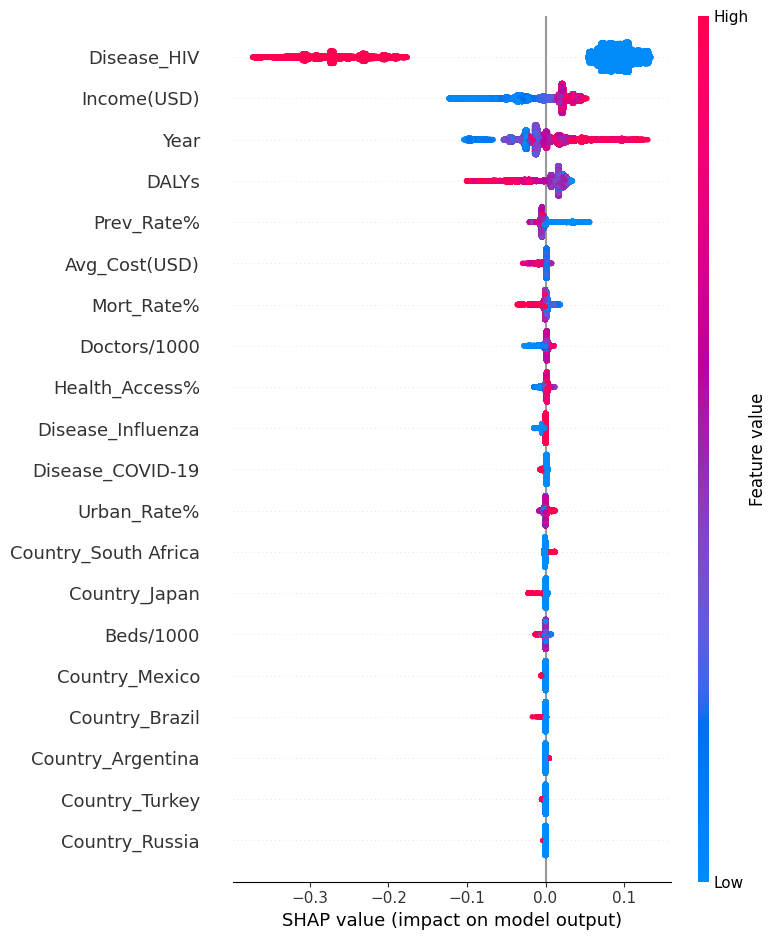


=== SHAP Feature Importance Scores (Descending Order) ===
             Feature  SHAP Importance
         Disease_HIV     1.353662e-01
         Income(USD)     2.997977e-02
                Year     2.612597e-02
               DALYs     2.284970e-02
          Prev_Rate%     6.296878e-03
       Avg_Cost(USD)     2.847532e-03
          Mort_Rate%     2.819756e-03
        Doctors/1000     2.722298e-03
      Health_Access%     2.243082e-03
   Disease_Influenza     1.684240e-03
    Disease_COVID-19     1.377328e-03
         Urban_Rate%     1.167287e-03
Country_South Africa     8.932580e-04
       Country_Japan     7.634821e-04
           Beds/1000     6.603110e-04
      Country_Mexico     3.140739e-04
      Country_Brazil     3.102608e-04
   Country_Argentina     2.588686e-04
      Country_Turkey     2.501082e-04
      Country_Russia     1.658860e-04
Country_Saudi Arabia     8.546039e-05
     Country_Nigeria     6.343998e-05
          Country_UK     1.697728e-05
 Country_South Korea     1.55

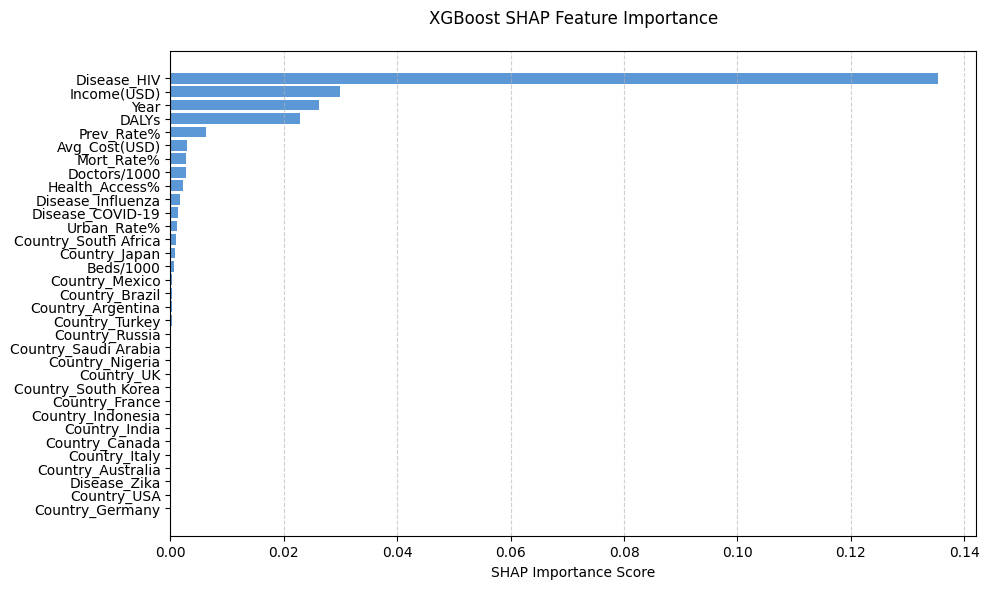

In [ ]:
import shap

explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

# 1. SHAP Summary Plot 
shap.summary_plot(shap_values, X_test)

shap_importance = np.abs(shap_values.values).mean(axis=0)

# Create a DataFrame for SHAP feature importance (sorted descendingly)
shap_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,  
    'SHAP Importance': shap_importance
}).sort_values('SHAP Importance', ascending=False)

print("\n=== SHAP Feature Importance Scores (Descending Order) ===")
print(shap_feature_importance.to_string(index=False))  

# Plot SHAP feature importance (horizontal bar chart)
plt.figure(figsize=(10, 6))
plt.barh(shap_feature_importance['Feature'], shap_feature_importance['SHAP Importance'], color='#5d98d6')
plt.gca().invert_yaxis()  
plt.xlabel('SHAP Importance Score')
plt.title('XGBoost SHAP Feature Importance', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Decision Tree - Tuned


Decision Tree RMSE: 0.037986440756120614
Decision Tree MSE: 0.001442969681318261
Decision Tree MAE: 0.029361828870842387
Decision Tree R²: 0.9625808227186112
Decision Tree SMAPE: 4.818212442236263%
Decision Tree Adjusted R²: 0.9625603238250325


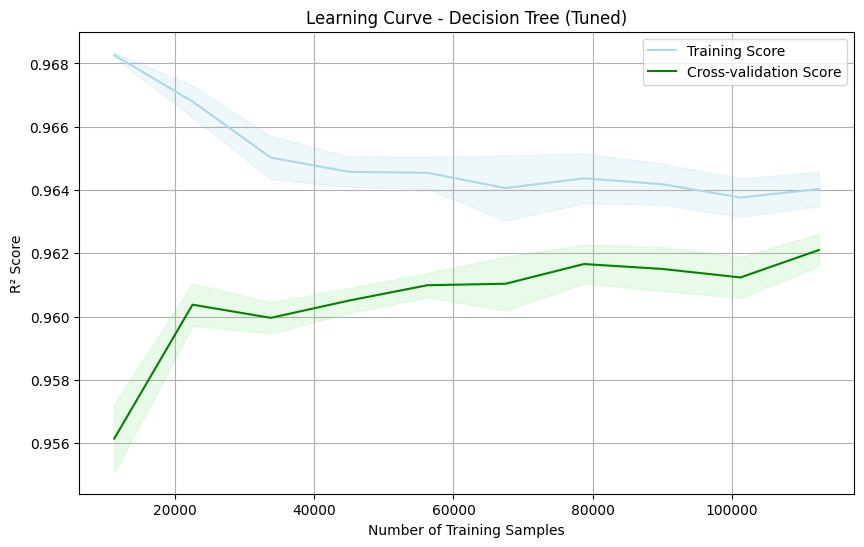


Merged Feature Importance :
Disease: 0.8245522371374782
Year: 0.0839281821602547
Income(USD): 0.05501955837703419
Health_Access%: 0.015214710270025383
Country: 0.011079867057696343
DALYs: 0.004518509266781326
Doctors/1000: 0.002921204189889663
Urban_Rate%: 0.0020394028954065545
Beds/1000: 0.0003531840121183588
Prev_Rate%: 0.00016303638348875004
Mort_Rate%: 0.000126275198218229
Avg_Cost(USD): 8.383305160839595e-05


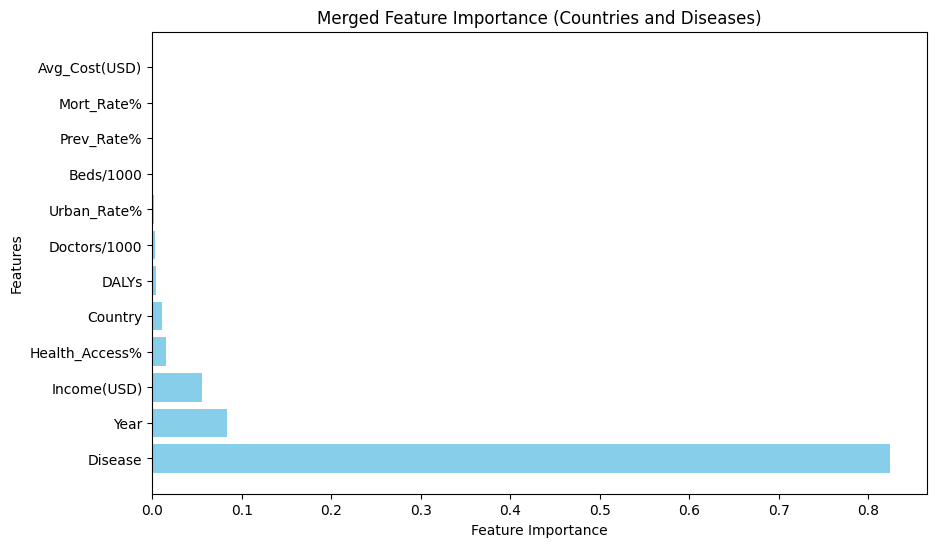

In [ ]:
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Best Parameters for Decision Tree
best_dt_params = {
    'ccp_alpha': 0.0,
    'criterion': 'friedman_mse',
    'max_depth': 10,
    'max_features': None,
    'max_leaf_nodes': None,
    'min_samples_leaf': 1,
    'min_samples_split': 20,
    'splitter': 'random'
}

# Initialize Decision Tree with best parameters
dt_model = DecisionTreeRegressor(**best_dt_params, random_state=42)
# Train the Decision Tree model
dt_model.fit(X_train, y_train)
# Make predictions
dt_preds = dt_model.predict(X_test)

# Calculate evaluation metrics
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mse = mean_squared_error(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)
smape = np.mean(2 * np.abs(dt_preds - y_test) / (np.abs(dt_preds) + np.abs(y_test))) * 100
# Adjusted R² Calculation
n = len(y_test)
p = X_train.shape[1]
dt_r2_adj = 1 - (1 - dt_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nDecision Tree RMSE: {dt_rmse}")
print(f"Decision Tree MSE: {dt_mse}")
print(f"Decision Tree MAE: {dt_mae}")
print(f"Decision Tree R²: {dt_r2}")
print(f"Decision Tree Adjusted R²: {dt_r2_adj}")
print(f"Decision Tree SMAPE: {smape}%")

# 1. Learning Curves
train_sizes, train_scores, test_scores = learning_curve(dt_model, X_train, y_train, cv=5, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="lightblue")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="green")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightblue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title('Learning Curve - Decision Tree (Tuned)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Feature Importance
feature_importance = dt_model.feature_importances_

# Define which columns belong to diseases and countries
country_columns = [col for col in X_train.columns if col.startswith('Country_')]
disease_columns = [col for col in X_train.columns if col.startswith('Disease_')]

# Merge feature importance for countries and diseases
country_importance = np.sum([feature_importance[X_train.columns.get_loc(col)] for col in country_columns])
disease_importance = np.sum([feature_importance[X_train.columns.get_loc(col)] for col in disease_columns])

# Create a new list with merged importance
merged_importance = {
    'Country': country_importance,
    'Disease': disease_importance
}

# Add other features' importance (non-country, non-disease)
for feature, importance in zip(X_train.columns, feature_importance):
    if feature not in country_columns and feature not in disease_columns:
        merged_importance[feature] = importance

# Print merged feature importance 
sorted_features = sorted(merged_importance.items(), key=lambda x: x[1], reverse=True)  # Change reverse to False
features, importances = zip(*sorted_features)

# Print sorted feature importance
print("\nMerged Feature Importance :")
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance}")

# Plot merged feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, importances, color="skyblue")
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Merged Feature Importance (Countries and Diseases)')
plt.show()



#### Linear Ridge Regression - Tuned


Linear Ridge Regression RMSE: 0.03922880475706603
Linear Ridge Regression MSE: 0.001538899122668006
Linear Ridge Regression MAE: 0.03021126786873386
Linear Ridge Regression R²: 0.9600931746281182
Linear Ridge Regression Adjusted R²: 0.9594868758832059
Linear Ridge Regression Tree SMAPE: 4.783401857154425%

Ridge Regression Coefficients:
Urban_Rate%: 0.06305862135716822
Income(USD): 0.04256323616087471
Year: 0.038113354797809605
Disease_Influenza: 0.03734116200749799
Disease_HIV: -0.03582989347489811
Edu_Index: 0.030087375495886616
Doctors/1000: 0.012253852607879574
Beds/1000: -0.01203433818148474
Country_India: 0.010312629017602054
Disease_COVID-19: -0.0092728313504665
Pop_Affected: -0.0073272782165942005
Health_Access%: 0.006714630515770342
Inc_Rate%: 0.005777006479221965
Avg_Cost(USD): -0.0055998802178386705
Country_Nigeria: 0.004191206427492024
Prev_Rate%: -0.0019559381349940333
Country_Argentina: -0.001931106686399046
Country_Brazil: -0.0015176694480377281
Country_South Africa: -0

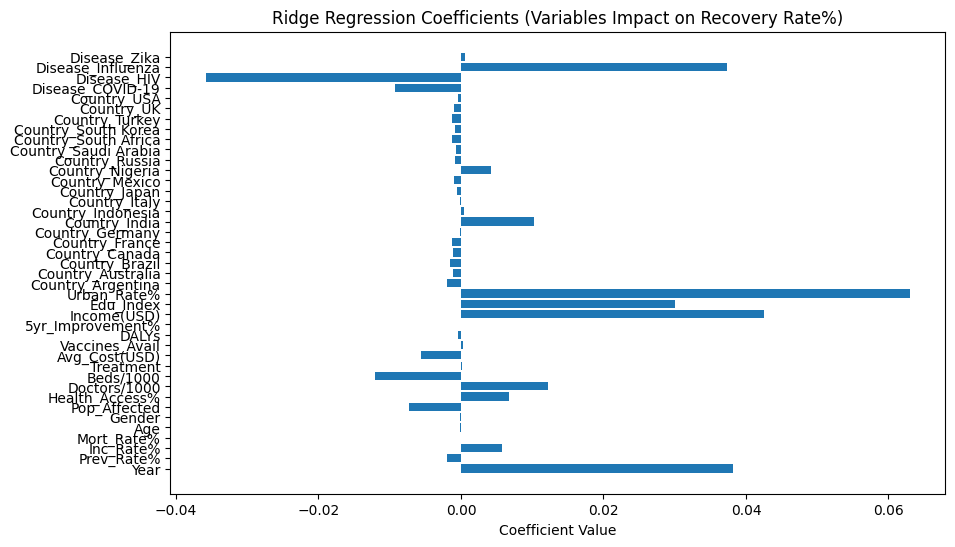

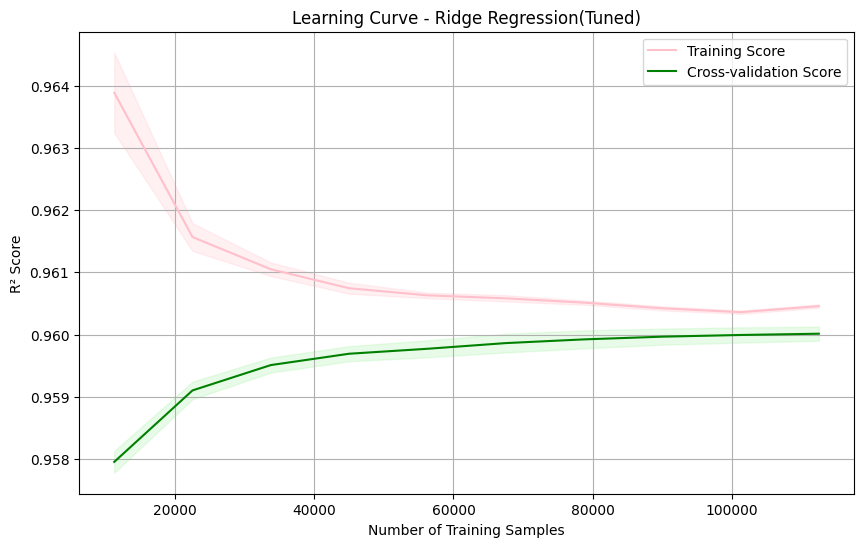

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

# Best Parameters for Ridge Regression
best_ridge_params = {'alpha': 6.21255072337672e-05}


# Add Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Initialize Ridge Regression with best parameters
ridge_model = Ridge(**best_ridge_params)
# Train the model
ridge_model.fit(X_train_poly, y_train)
# Make predictions
ridge_preds = ridge_model.predict(X_test_poly)

# Calculate evaluation metrics
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)
smape = np.mean(2 * np.abs(xgb_preds - y_test) / (np.abs(xgb_preds) + np.abs(y_test))) * 100
# Adjusted R² Calculation
n = len(y_test)
p = X_train_poly.shape[1]
ridge_r2_adj = 1 - (1 - ridge_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nLinear Ridge Regression RMSE: {ridge_rmse}")
print(f"Linear Ridge Regression MSE: {ridge_mse}")
print(f"Linear Ridge Regression MAE: {ridge_mae}")
print(f"Linear Ridge Regression R²: {ridge_r2}")
print(f"Linear Ridge Regression Adjusted R²: {ridge_r2_adj}")
print(f"Linear Ridge Regression Tree SMAPE: {smape}%")

# 1. Coefficients of the best model
ridge_coefficients = ridge_model.coef_

# Get coefficients and feature names for main variables only (exclude interaction terms)
main_coefficients = ridge_coefficients[:len(X_train.columns)]
feature_names = X_train.columns

# Sort by absolute value of coefficients (descending)
sorted_indices = np.argsort(np.abs(main_coefficients))[::-1]
sorted_features = feature_names[sorted_indices]
sorted_coeffs = main_coefficients[sorted_indices]

print("\nRidge Regression Coefficients:")
for feature, coefficient in zip(sorted_features, sorted_coeffs):
    print(f"{feature}: {coefficient}")


# Plot coefficients for interpretation
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, ridge_coefficients[:len(X_train.columns)])
plt.xlabel('Coefficient Value')
plt.title('Ridge Regression Coefficients (Variables Impact on Recovery Rate%)')
plt.show()

# 2. Learning Curves
train_sizes, train_scores, test_scores = learning_curve(ridge_model, X_train_poly, y_train, cv=5, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="pink")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="green")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightpink")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title('Learning Curve - Ridge Regression(Tuned)')
plt.legend()
plt.grid(True)
plt.show()



#### Bayesian Ridge Regression - Tuned


Bayesian Ridge RMSE: 0.03944943426001463
Bayesian Ridge MSE: 0.001556257863435216
Bayesian Ridge MAE: 0.03032727968649088
Bayesian Ridge R²: 0.9596430267098636
Bayesian Ridge Adjusted R²: 0.9592413369391886
Bayesian Ridge Regression Tree SMAPE: 4.743018601063144%

Bayesian Ridge Regression Coefficients for Variables and Target Variable Relationship:
Income(USD): 0.0524381113165877
Year: 0.04153431757252061
DALYs: -0.00041581989200875375
Mort_Rate%: 4.3840350192935265e-06
Prev_Rate%: -0.0016470551796181065
Doctors/1000: 0.01506917964357622
Urban_Rate%: 0.07047837316995209
Health_Access%: 0.007955221678845353
Avg_Cost(USD): -0.0068912622180067416
Beds/1000: -0.013618945384193141
Disease_COVID-19: -0.014563421693425895
Disease_HIV: -0.0398189010191009
Disease_Influenza: 0.04397877554115755
Disease_Zika: 0.0017486316753172304
Country_Argentina: -0.0021493000606782114
Country_Australia: -0.0016733366586946183
Country_Brazil: -0.0012997684045291111
Country_Canada: -0.0012861102709993363
Cou

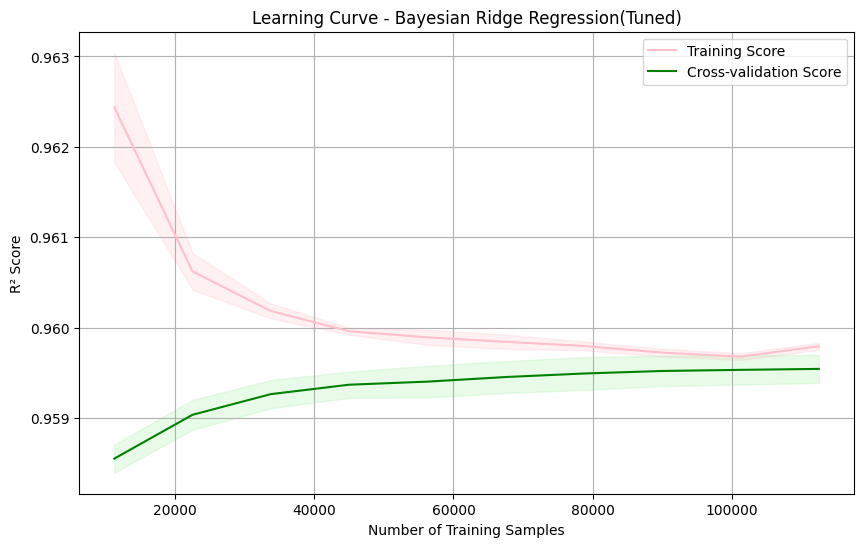

In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

# Best Parameters for Bayesian Ridge Regression
best_bayesian_params = {
    'alpha_1': 1.0502436637900069e-06,
    'alpha_2': 3.2173324445536204e-05,
    'lambda_1': 1.727143828076896e-05,
    'lambda_2': 0.09979595483121105
}

# Add Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Initialize Bayesian Ridge model with best parameters
bayesian_ridge_model = BayesianRidge(**best_bayesian_params)
# Train the model
bayesian_ridge_model.fit(X_train_poly, y_train)
# Make predictions
bayesian_ridge_preds = bayesian_ridge_model.predict(X_test_poly)

# Calculate evaluation metrics
bayesian_ridge_rmse = np.sqrt(mean_squared_error(y_test, bayesian_ridge_preds))
bayesian_ridge_mse = mean_squared_error(y_test, bayesian_ridge_preds)
bayesian_ridge_mae = mean_absolute_error(y_test, bayesian_ridge_preds)
bayesian_ridge_r2 = r2_score(y_test, bayesian_ridge_preds)
smape = np.mean(2 * np.abs(xgb_preds - y_test) / (np.abs(xgb_preds) + np.abs(y_test))) * 100
# Adjusted R² Calculation
n = len(y_test)
p = X_train_poly.shape[1]
bayesian_ridge_r2_adj = 1 - (1 - bayesian_ridge_r2) * (n - 1) / (n - p - 1)

# Print results
print(f"\nBayesian Ridge RMSE: {bayesian_ridge_rmse}")
print(f"Bayesian Ridge MSE: {bayesian_ridge_mse}")
print(f"Bayesian Ridge MAE: {bayesian_ridge_mae}")
print(f"Bayesian Ridge R²: {bayesian_ridge_r2}")
print(f"Bayesian Ridge Adjusted R²: {bayesian_ridge_r2_adj}")
print(f"Bayesian Ridge Regression Tree SMAPE: {smape}%")

# 1. Coefficients of the best model
bayesian_ridge_coefficients = bayesian_ridge_model.coef_

# Print the coefficients for the main variables only (not interactions)
print("\nBayesian Ridge Regression Coefficients for Variables and Target Variable Relationship:")
for feature, coefficient in zip(poly.get_feature_names_out(X_train.columns), bayesian_ridge_coefficients[:len(X_train.columns)]):
    print(f"{feature}: {coefficient}")


# 2. Learning Curves
train_sizes, train_scores, test_scores = learning_curve(bayesian_ridge_model, X_train_poly, y_train, cv=5, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="pink")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color="green")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="lightpink")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="lightgreen")
plt.xlabel("Number of Training Samples")
plt.ylabel('R² Score')
plt.title('Learning Curve - Bayesian Ridge Regression(Tuned)')
plt.legend()
plt.grid(True)
plt.show()

### 7.0 Deployment

#### Export Final Best Model - XGBoost

In [55]:
import pickle

# Save the model to a file
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
